# NHS PROMs — Comprehensive Correlation Analysis
## Hip & Knee Replacement Provider Data

**Source datasets:**
- `notebooks/Final/data/hip-provider.parquet` — Hip Replacement (n ≈ 111k, 48 columns)
- `notebooks/Final/data/Knee-provider.parquet` — Knee Replacement (n ≈ 129k, 48 columns)

**Outcome variables:**
- Hip: `Hip Replacement Post-Op Q Score` (Oxford Hip Score, OHS, 0–48)
- Knee: `Knee Replacement Post-Op Q Score` (Oxford Knee Score, OKS, 0–48)

**Analysis structure**
1. Full Spearman correlation matrix (all numeric features)
2. Ranked correlations with outcome — all pre-op features
3. Scatter plots — top predictors vs outcome
4. Box plots — outcome by demographics (Gender, Age Band, Living Arrangements)
5. EQ VAS ↔ disease-specific score analysis (extends `correlation-eqvas-ohs.ipynb`)
6. EQ-5D dimensions ↔ outcome
7. Cross-dataset comparison (Hip vs Knee correlation patterns)

## 0 · Imports & configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

# ── Plot style ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

BLUE   = '#2471A3'
ORANGE = '#CA6F1E'
GREEN  = '#1E8449'
RED    = '#C0392B'

print('Libraries loaded.')

Libraries loaded.


## 1 · Load prepared datasets

In [2]:
HIP_PATH   = Path('data/hip-provider.parquet')
KNEE_PATH  = Path('data/Knee-provider.parquet')

hip  = pd.read_parquet(HIP_PATH)
knee = pd.read_parquet(KNEE_PATH)

HIP_OUTCOME  = 'Hip Replacement Post-Op Q Score'
KNEE_OUTCOME = 'Knee Replacement Post-Op Q Score'

print(f'Hip  dataset : {hip.shape[0]:,} rows × {hip.shape[1]} columns')
print(f'Knee dataset : {knee.shape[0]:,} rows × {knee.shape[1]} columns')

Hip  dataset : 111,123 rows × 48 columns
Knee dataset : 129,450 rows × 48 columns


## 2 · Helper functions

In [3]:
# ── Columns to EXCLUDE from numeric correlation (encoded/non-ordinal) ──────────
# EQ5D Index Profile stores a 5-digit concatenated integer (e.g. 22231);
# treating it as a continuous number would produce meaningless correlations.
EXCLUDE = {
    'Pre-Op Q EQ5D Index Profile',
    'Post-Op Q EQ5D Index Profile',
    'Pre-Op Q Assisted By',   # constant in most rows (0 = self-completed)
}

def numeric_cols(df, exclude=EXCLUDE):
    """Return numeric column names, dropping excluded and all-NaN columns."""
    cols = df.select_dtypes(include='number').columns.tolist()
    cols = [c for c in cols if c not in exclude]
    cols = [c for c in cols if df[c].notna().any()]
    return cols

def preop_cols(df, outcome):
    """Return only pre-operative numeric features (no post-op leakage)."""
    all_num = numeric_cols(df)
    # Exclude outcome itself and any post-op columns
    return [c for c in all_num
            if c != outcome
            and 'Post-Op' not in c
            and 'post_op' not in c.lower()]

def spearman_with_outcome(df, features, outcome):
    """Return a DataFrame of Spearman r and p-value for each feature vs outcome."""
    rows = []
    y = df[outcome].dropna()
    for feat in features:
        x = df[feat]
        pair = pd.concat([x, y], axis=1).dropna()
        if len(pair) < 30:
            continue
        r, p = stats.spearmanr(pair.iloc[:, 0], pair.iloc[:, 1])
        rows.append({'feature': feat, 'spearman_r': r, 'p_value': p, 'n': len(pair)})
    return pd.DataFrame(rows).sort_values('spearman_r', ascending=False)

def significance_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print('Helper functions defined.')

Helper functions defined.


---
# PART A — Hip Replacement

## A1 · Full Spearman correlation matrix (all numeric features)

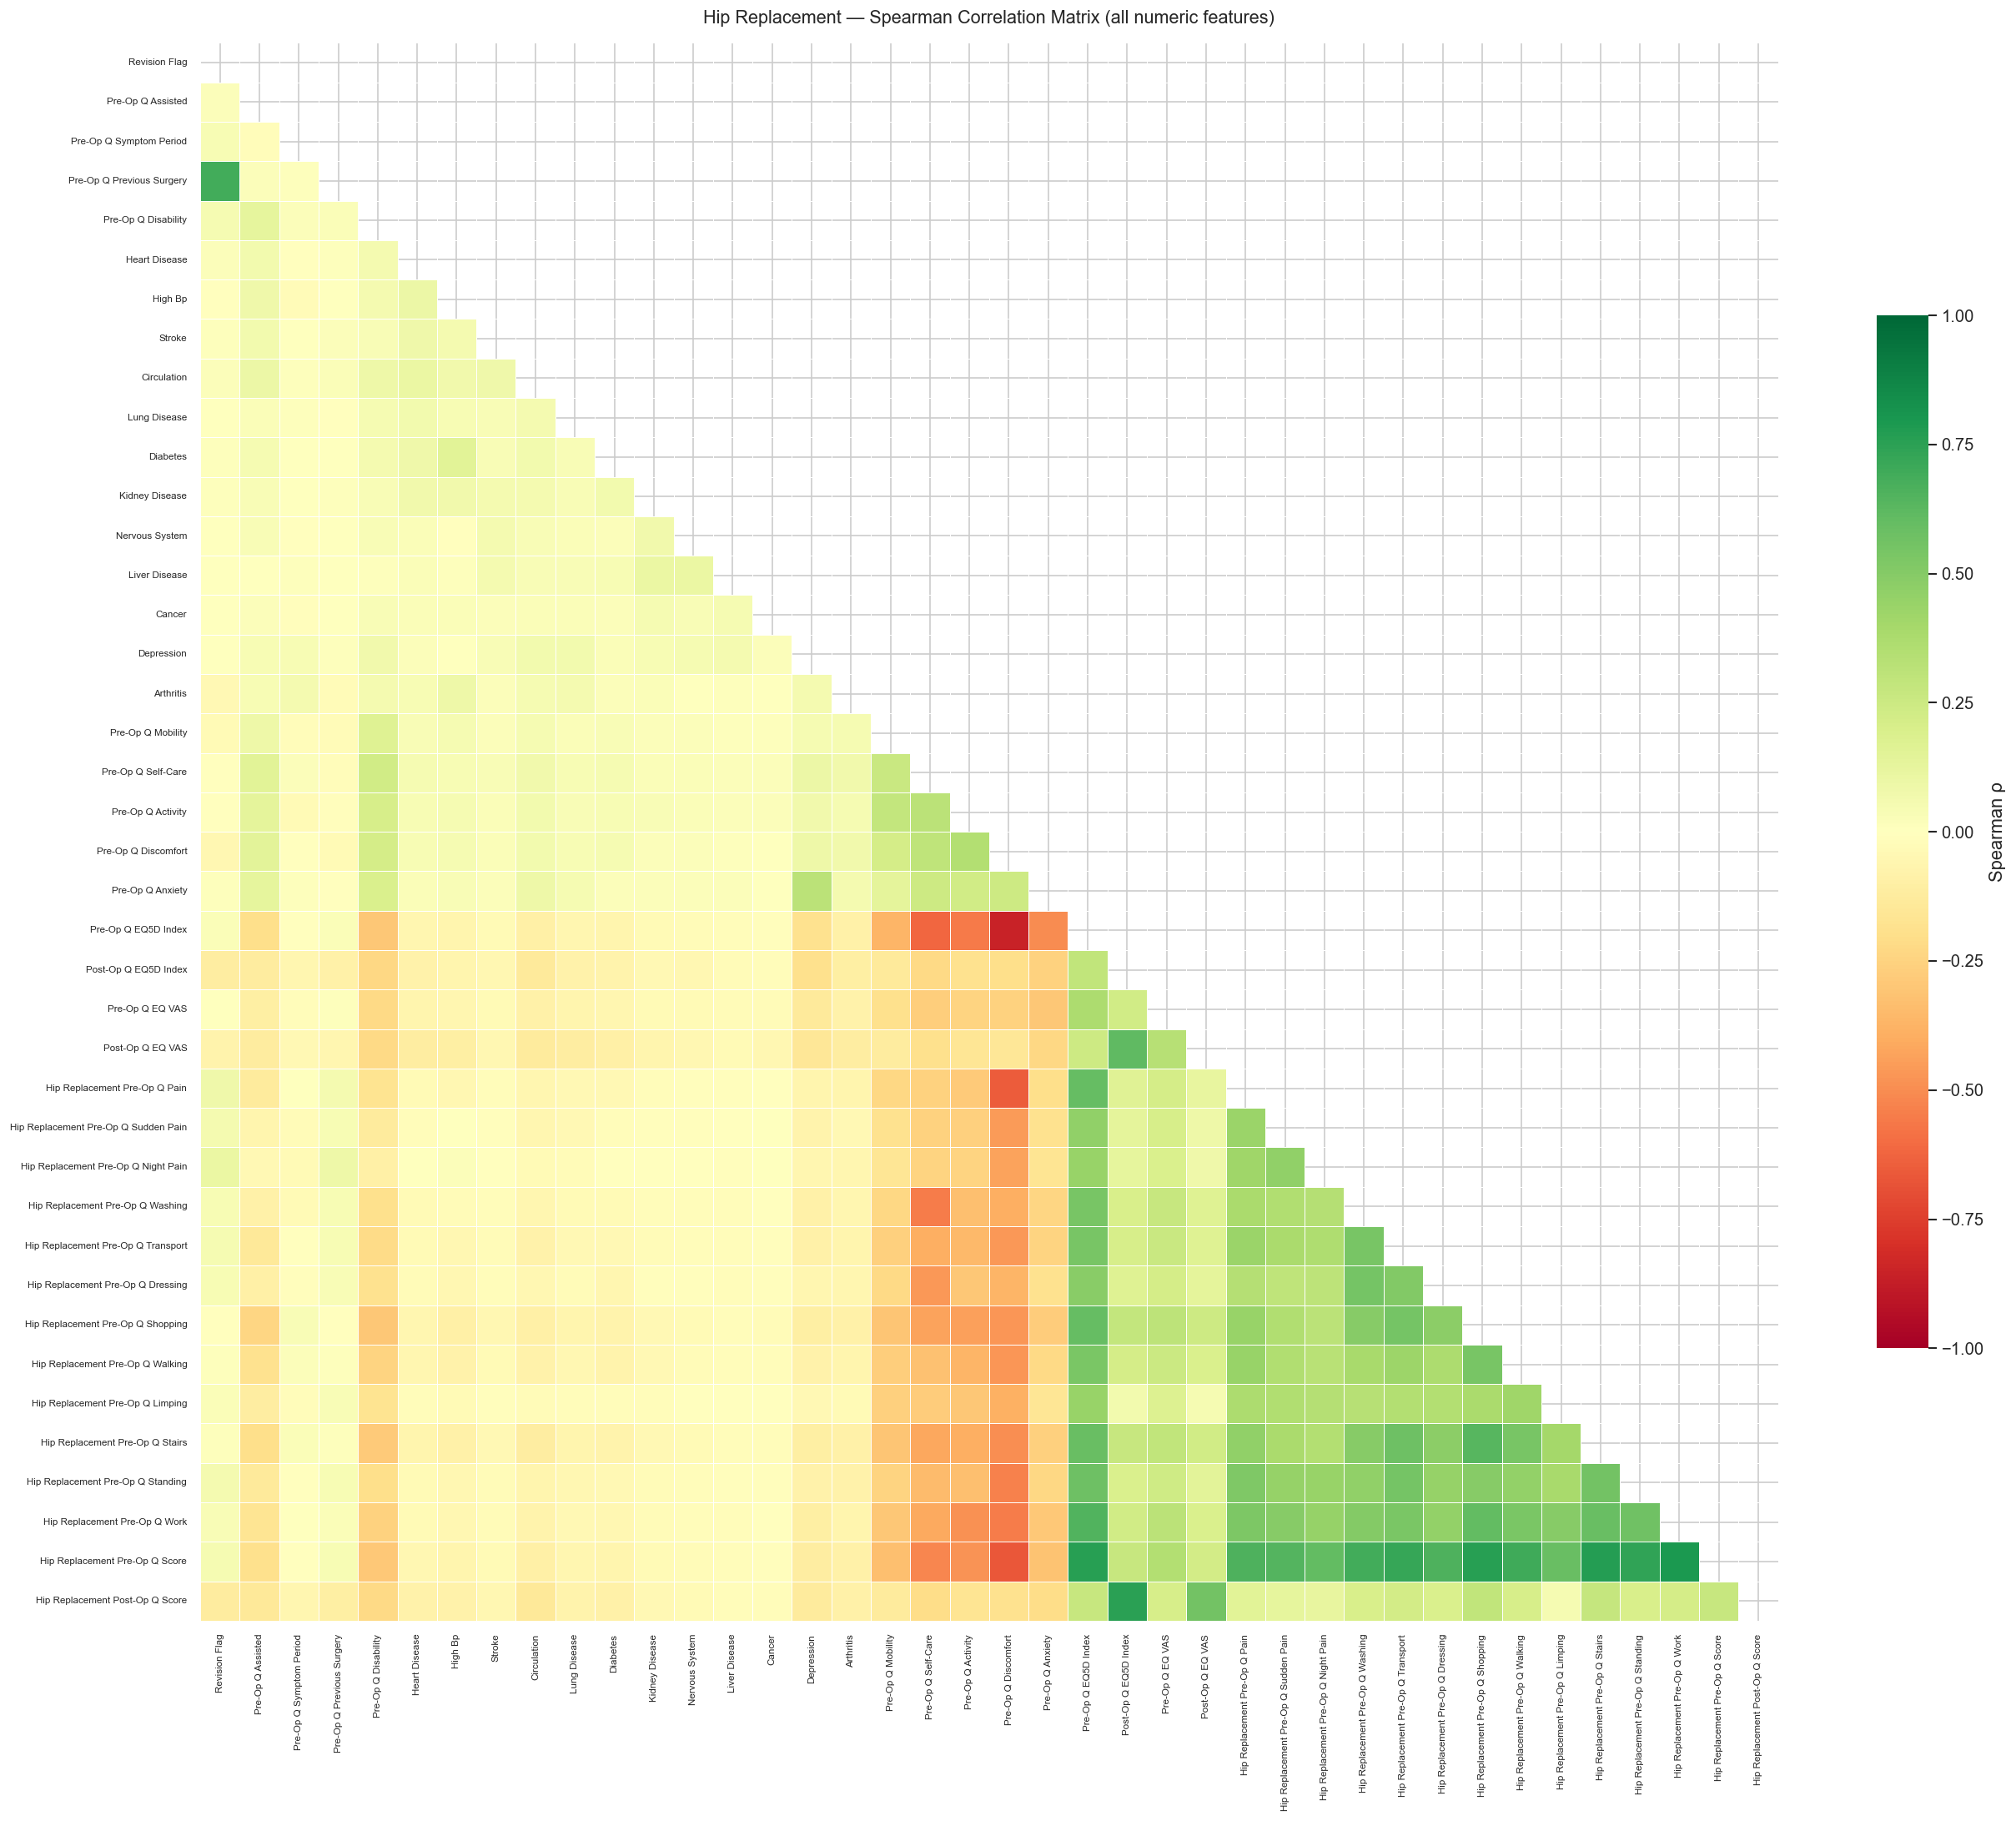

Matrix size: 40 × 40


In [4]:
hip_num_cols = numeric_cols(hip)
hip_corr = hip[hip_num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(22, 19))
mask = np.triu(np.ones_like(hip_corr, dtype=bool))  # show lower triangle only

sns.heatmap(
    hip_corr, mask=mask,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    annot=False,          # too many cells for annotation
    square=True, ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Spearman ρ'}
)
ax.set_title('Hip Replacement — Spearman Correlation Matrix (all numeric features)', pad=14)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig('hip_full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Matrix size: {hip_corr.shape[0]} × {hip_corr.shape[1]}')

## A2 · Ranked correlations — pre-operative features vs OHS outcome

Only **pre-operative** columns are included here to avoid data leakage.  
Post-op columns cannot be known at prediction time.

In [7]:
hip_preop = preop_cols(hip, HIP_OUTCOME)
hip_rank  = spearman_with_outcome(hip, hip_preop, HIP_OUTCOME)

print(f'Pre-op features assessed: {len(hip_rank)}')
print('\nTop 10 positive correlations with OHS post-op:')
print(hip_rank.head(10).to_string(index=False))
print('\nTop 10 negative correlations with OHS post-op:')
print(hip_rank.tail(10).to_string(index=False))

Pre-op features assessed: 37

Top 10 positive correlations with OHS post-op:
                           feature  spearman_r  p_value      n
 Hip Replacement Pre-Op Q Shopping      0.2901      0.0 110183
   Hip Replacement Pre-Op Q Stairs      0.2808      0.0 110183
    Hip Replacement Pre-Op Q Score      0.2723      0.0 110183
               Pre-Op Q EQ5D Index      0.2657      0.0 110183
Hip Replacement Pre-Op Q Transport      0.2238      0.0 110183
     Hip Replacement Pre-Op Q Work      0.2143      0.0 110183
  Hip Replacement Pre-Op Q Walking      0.2091      0.0 110183
                   Pre-Op Q EQ VAS      0.2085      0.0 103898
 Hip Replacement Pre-Op Q Standing      0.2003      0.0 110183
  Hip Replacement Pre-Op Q Washing      0.1983      0.0 110183

Top 10 negative correlations with OHS post-op:
            feature  spearman_r  p_value      n
      Revision Flag     -0.1243      0.0 110183
  Pre-Op Q Mobility     -0.1270      0.0 110183
         Depression     -0.1283      0

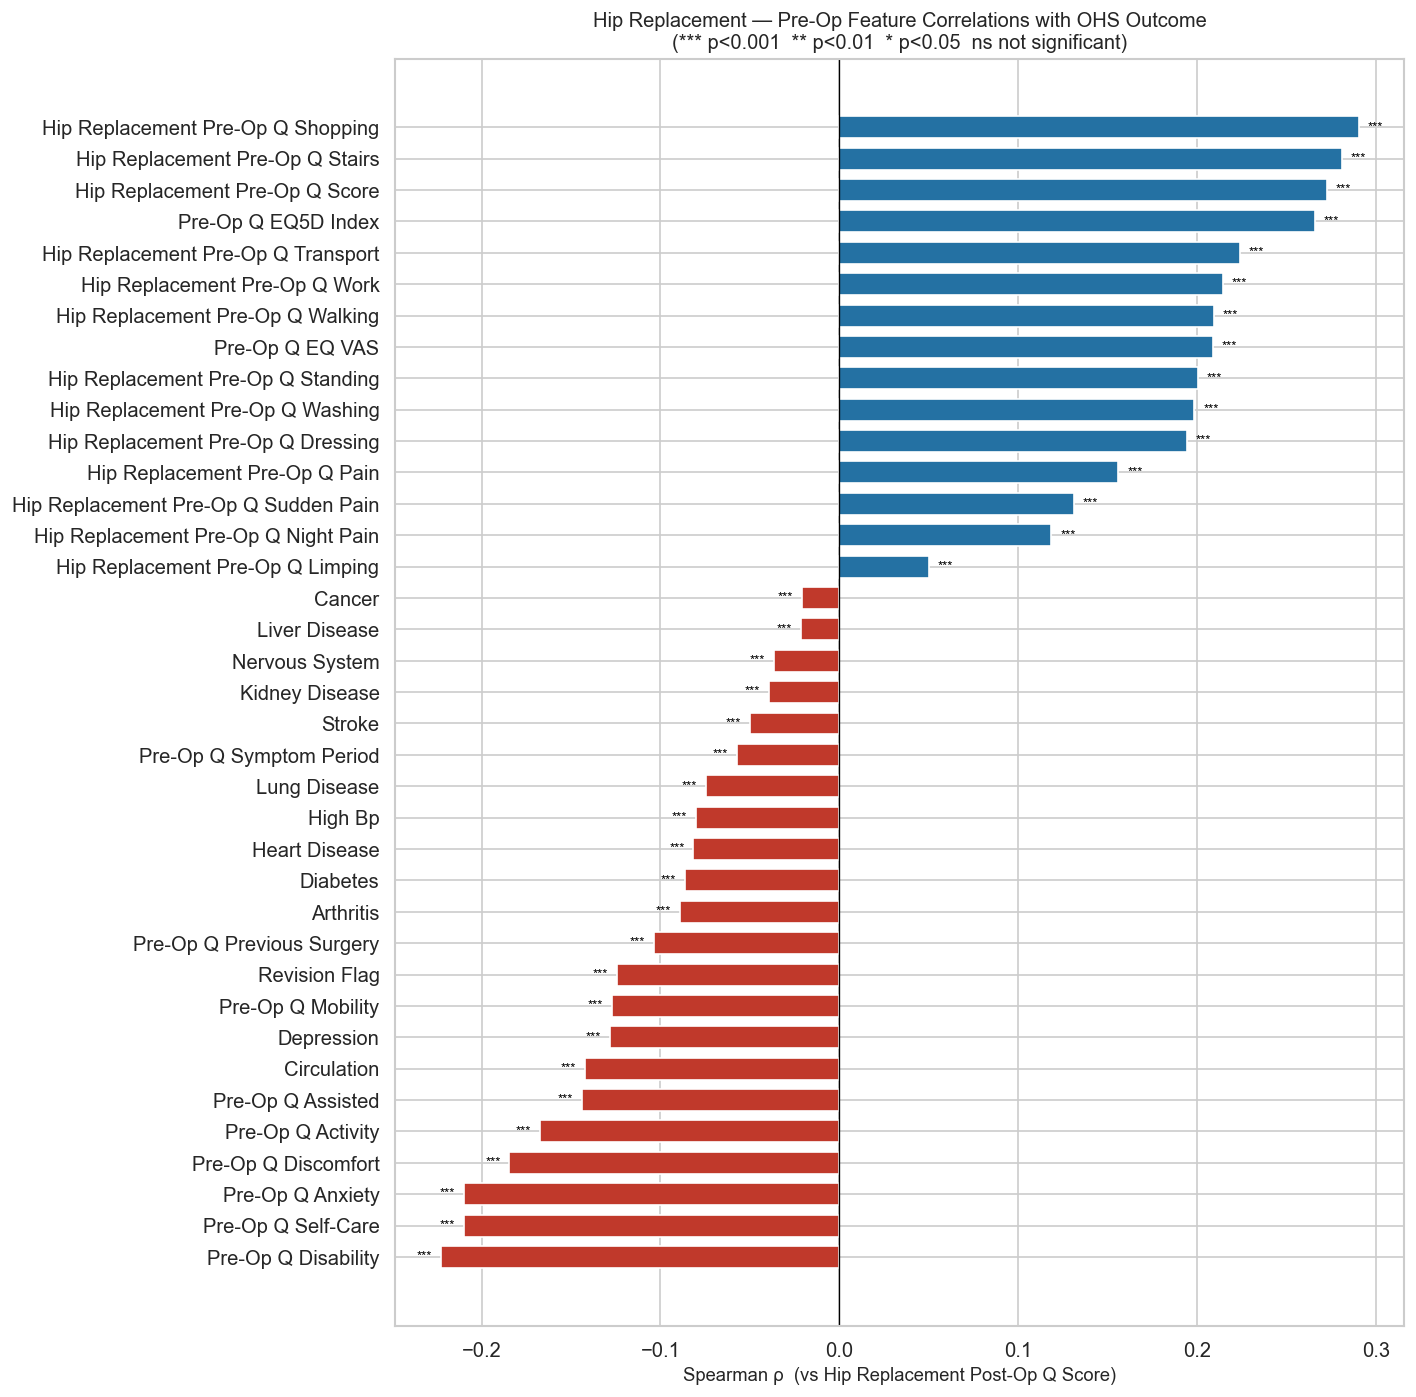

In [8]:
# Bar chart: all pre-op features ranked by Spearman r
fig, ax = plt.subplots(figsize=(12, max(6, len(hip_rank) * 0.32)))

colors = [BLUE if r >= 0 else RED for r in hip_rank['spearman_r']]
bars = ax.barh(hip_rank['feature'], hip_rank['spearman_r'], color=colors, edgecolor='white', height=0.7)

# Add significance stars
for bar, (_, row) in zip(bars, hip_rank.iterrows()):
    stars = significance_stars(row['p_value'])
    x = bar.get_width()
    ax.text(x + (0.005 if x >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            stars, va='center', ha='left' if x >= 0 else 'right', fontsize=8, color='black')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ  (vs Hip Replacement Post-Op Q Score)', fontsize=11)
ax.set_title('Hip Replacement — Pre-Op Feature Correlations with OHS Outcome\n'
             '(*** p<0.001  ** p<0.01  * p<0.05  ns not significant)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('hip_preop_correlations_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## A3 · Scatter plots — top 6 pre-op predictors vs OHS outcome

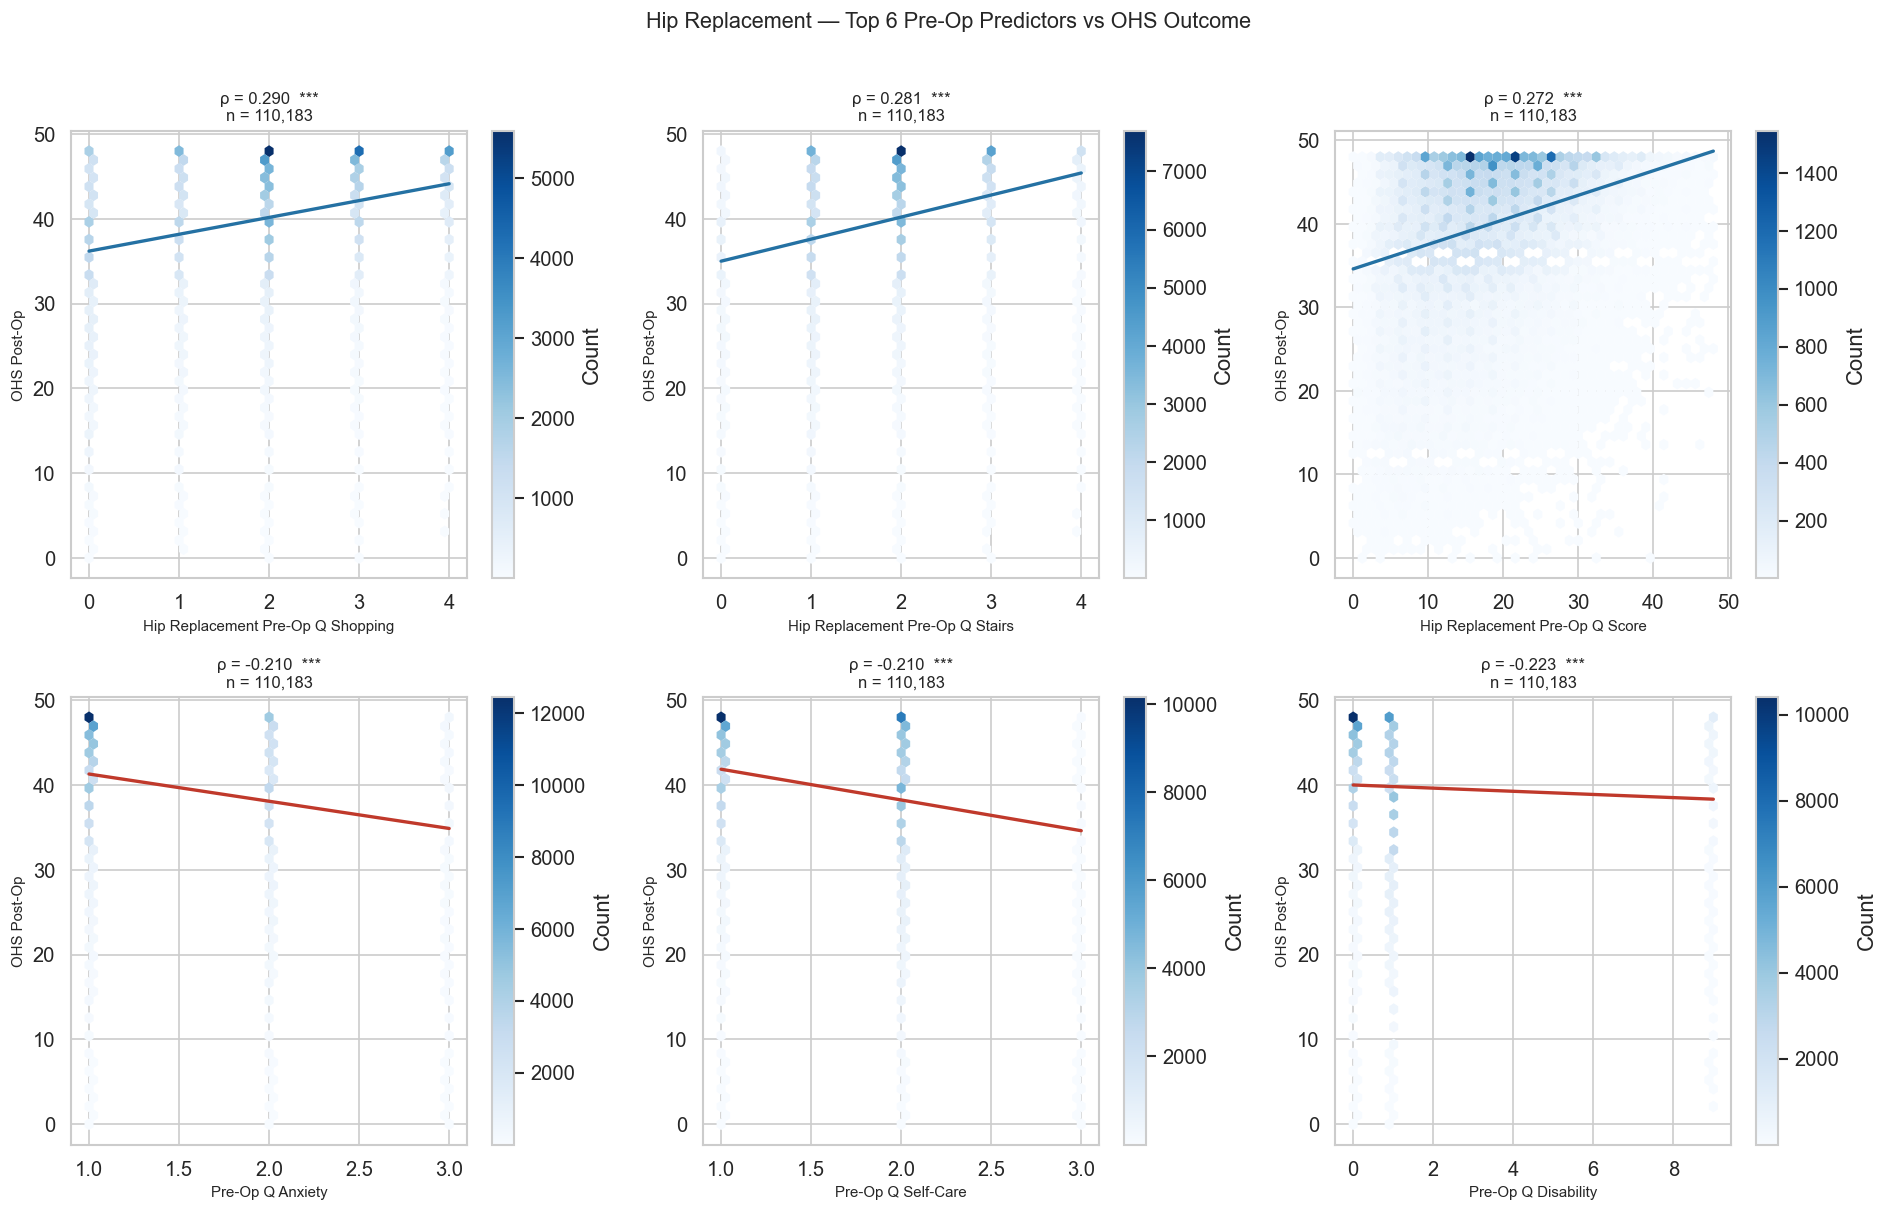

In [9]:
# Select top 3 positive and top 3 (most negative) predictors
top_pos = hip_rank.head(3)['feature'].tolist()
top_neg = hip_rank.tail(3)['feature'].tolist()
top6    = top_pos + top_neg

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top6):
    ax = axes[i]
    pair = hip[[feat, HIP_OUTCOME]].dropna()
    r, p = stats.spearmanr(pair[feat], pair[HIP_OUTCOME])
    color = BLUE if r >= 0 else RED

    # Hex-bin to handle overplotting
    hb = ax.hexbin(pair[feat], pair[HIP_OUTCOME], gridsize=40, cmap='Blues', mincnt=1, linewidths=0)
    plt.colorbar(hb, ax=ax, label='Count')

    # OLS regression line
    m, b, *_ = stats.linregress(pair[feat], pair[HIP_OUTCOME])
    x_line = np.linspace(pair[feat].min(), pair[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color=color, linewidth=2)

    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('OHS Post-Op', fontsize=9)
    ax.set_title(f'ρ = {r:.3f}  {significance_stars(p)}\nn = {len(pair):,}', fontsize=10)

plt.suptitle('Hip Replacement — Top 6 Pre-Op Predictors vs OHS Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hip_top6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## A4 · Outcome by demographics — Gender, Age Band, Living Arrangements

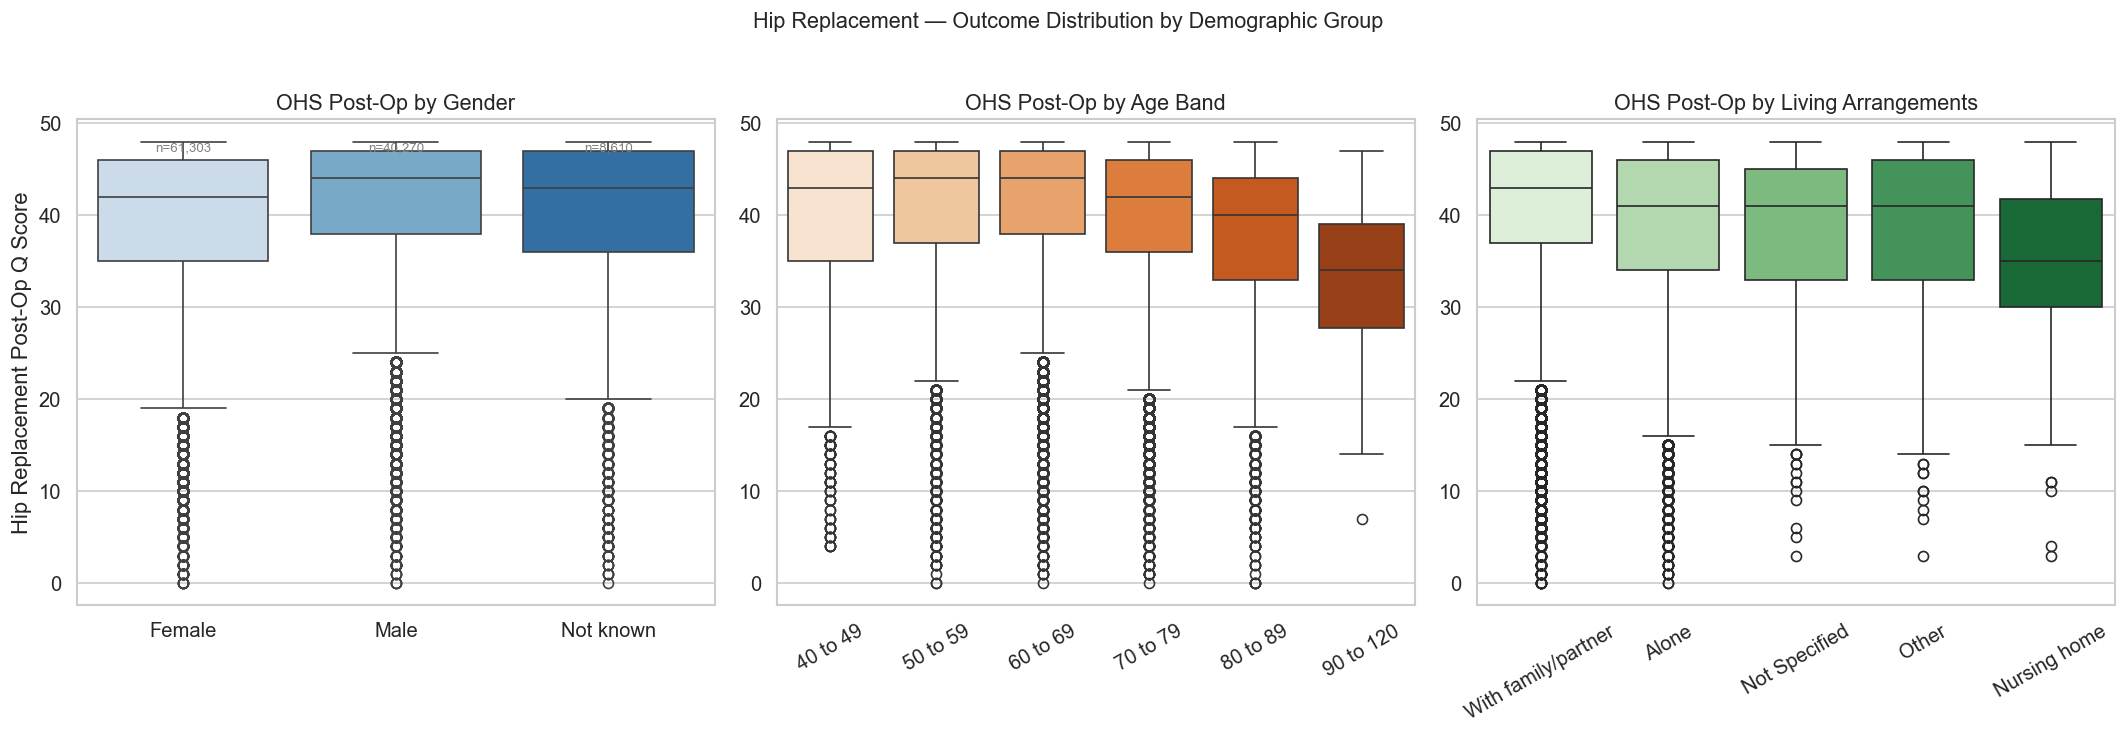

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gender
gender_order = hip.dropna(subset=[HIP_OUTCOME])['Gender'].value_counts().index.tolist()
sns.boxplot(data=hip.dropna(subset=[HIP_OUTCOME]), x='Gender', y=HIP_OUTCOME,
            order=gender_order, palette='Blues', ax=axes[0])
axes[0].set_title('OHS Post-Op by Gender')
axes[0].set_xlabel('')
axes[0].set_ylabel('Hip Replacement Post-Op Q Score')
for gender in gender_order:
    n = hip[hip['Gender'] == gender][HIP_OUTCOME].dropna().shape[0]
    axes[0].text(gender_order.index(gender), hip[HIP_OUTCOME].max() * 0.98,
                 f'n={n:,}', ha='center', fontsize=8, color='grey')

# Age Band
age_order = ['40 to 49', '50 to 59', '60 to 69', '70 to 79', '80 to 89', '90 to 120']
age_order = [a for a in age_order if a in hip['Age Band'].dropna().unique()]
sns.boxplot(data=hip.dropna(subset=[HIP_OUTCOME]), x='Age Band', y=HIP_OUTCOME,
            order=age_order, palette='Oranges', ax=axes[1])
axes[1].set_title('OHS Post-Op by Age Band')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

# Living Arrangements
living_order = hip.dropna(subset=[HIP_OUTCOME, 'Pre-Op Q Living Arrangements'])\
                  .groupby('Pre-Op Q Living Arrangements')[HIP_OUTCOME].median()\
                  .sort_values(ascending=False).index.tolist()
short_labels = {
    'Living with partner/spouse/family/friends': 'With family/partner',
    'Living in a nursing home, hospital or other long-term care home': 'Nursing home',
    'Alone': 'Alone', 'Other': 'Other', 'Not Specified': 'Not Specified'
}
hip_plot = hip.dropna(subset=[HIP_OUTCOME]).copy()
hip_plot['Living'] = hip_plot['Pre-Op Q Living Arrangements'].map(short_labels).fillna(hip_plot['Pre-Op Q Living Arrangements'])
living_order_short = [short_labels.get(l, l) for l in living_order]
sns.boxplot(data=hip_plot, x='Living', y=HIP_OUTCOME,
            order=living_order_short, palette='Greens', ax=axes[2])
axes[2].set_title('OHS Post-Op by Living Arrangements')
axes[2].set_xlabel('')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Hip Replacement — Outcome Distribution by Demographic Group', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('hip_demographics_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## A5 · EQ VAS ↔ OHS (extends `correlation-eqvas-ohs.ipynb`)

Reproduces and extends the analysis from `notebooks/Lalita/correlation-eqvas-ohs.ipynb`  
using the fully prepared dataset, now covering both pre-operative and post-operative EQ VAS.

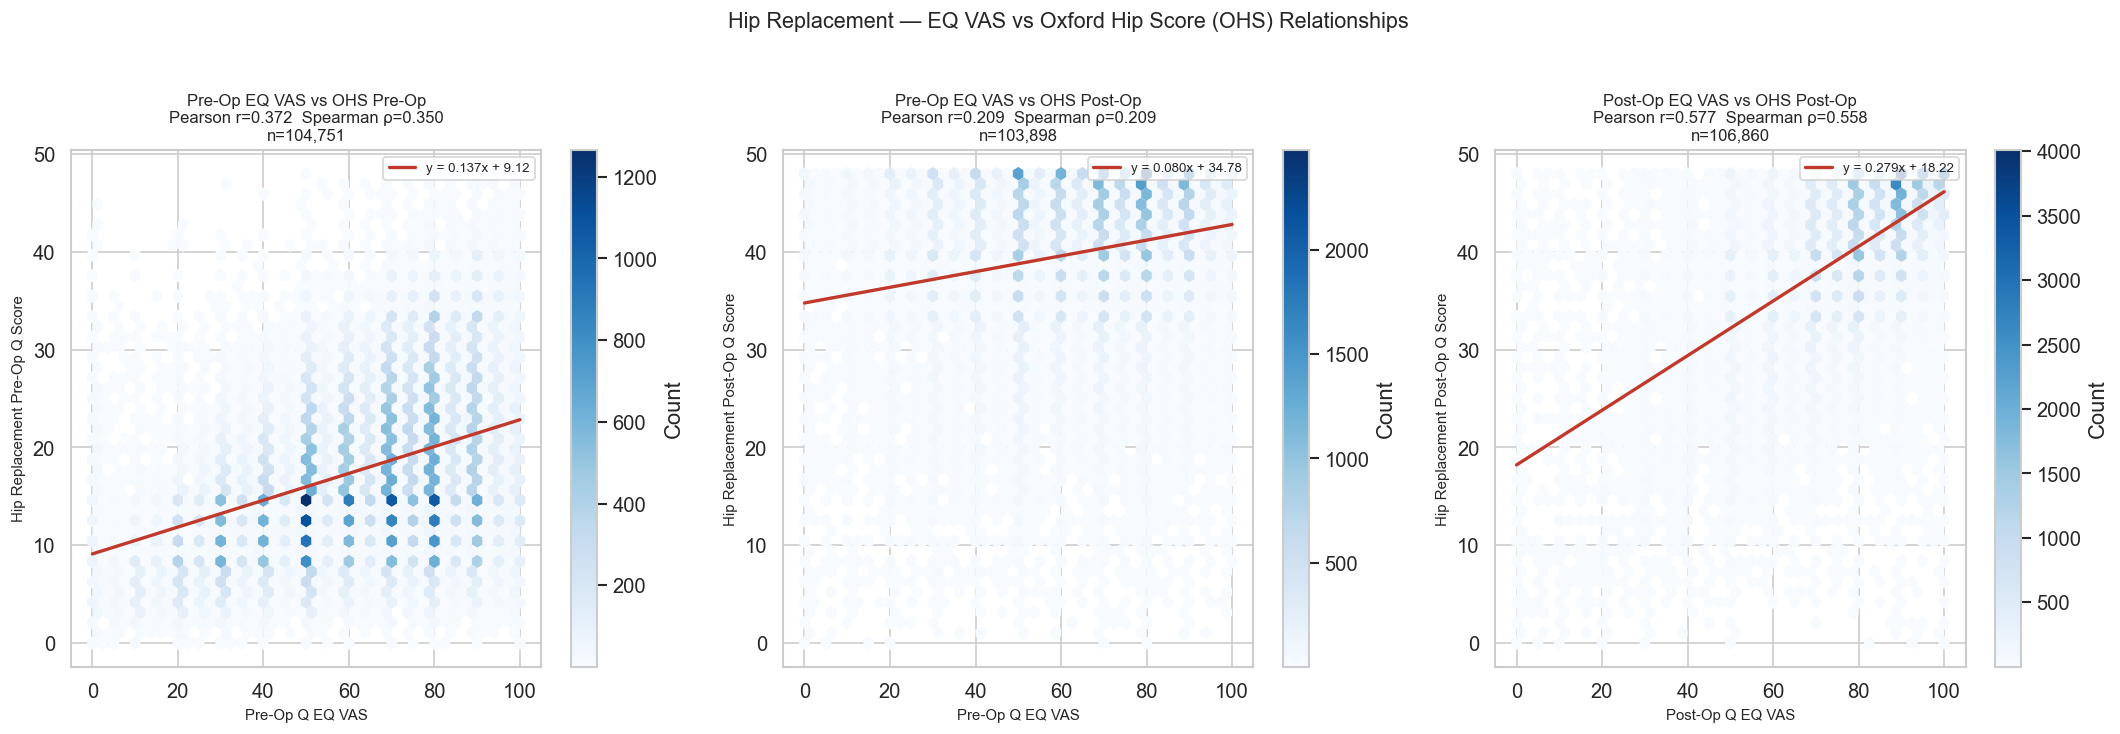

In [11]:
# ── Pre-op: EQ VAS vs OHS pre-op score ────────────────────────────────────────
pairs = {
    'Pre-Op EQ VAS vs OHS Pre-Op':  ('Pre-Op Q EQ VAS',  'Hip Replacement Pre-Op Q Score'),
    'Pre-Op EQ VAS vs OHS Post-Op': ('Pre-Op Q EQ VAS',  HIP_OUTCOME),
    'Post-Op EQ VAS vs OHS Post-Op':('Post-Op Q EQ VAS', HIP_OUTCOME),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, (xcol, ycol)) in zip(axes, pairs.items()):
    pair = hip[[xcol, ycol]].dropna()
    pearson_r,  pearson_p  = stats.pearsonr(pair[xcol], pair[ycol])
    spearman_r, spearman_p = stats.spearmanr(pair[xcol], pair[ycol])

    hb = ax.hexbin(pair[xcol], pair[ycol], gridsize=40, cmap='Blues', mincnt=1, linewidths=0)
    plt.colorbar(hb, ax=ax, label='Count')

    m, b, *_ = stats.linregress(pair[xcol], pair[ycol])
    x_line = np.linspace(pair[xcol].min(), pair[xcol].max(), 100)
    ax.plot(x_line, m * x_line + b, color=RED, linewidth=2,
            label=f'y = {m:.3f}x + {b:.2f}')

    ax.set_xlabel(xcol, fontsize=9)
    ax.set_ylabel(ycol, fontsize=9)
    ax.set_title(f'{title}\nPearson r={pearson_r:.3f}  Spearman ρ={spearman_r:.3f}\nn={len(pair):,}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Hip Replacement — EQ VAS vs Oxford Hip Score (OHS) Relationships', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('hip_eqvas_ohs_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## A6 · EQ-5D dimensions ↔ OHS outcome

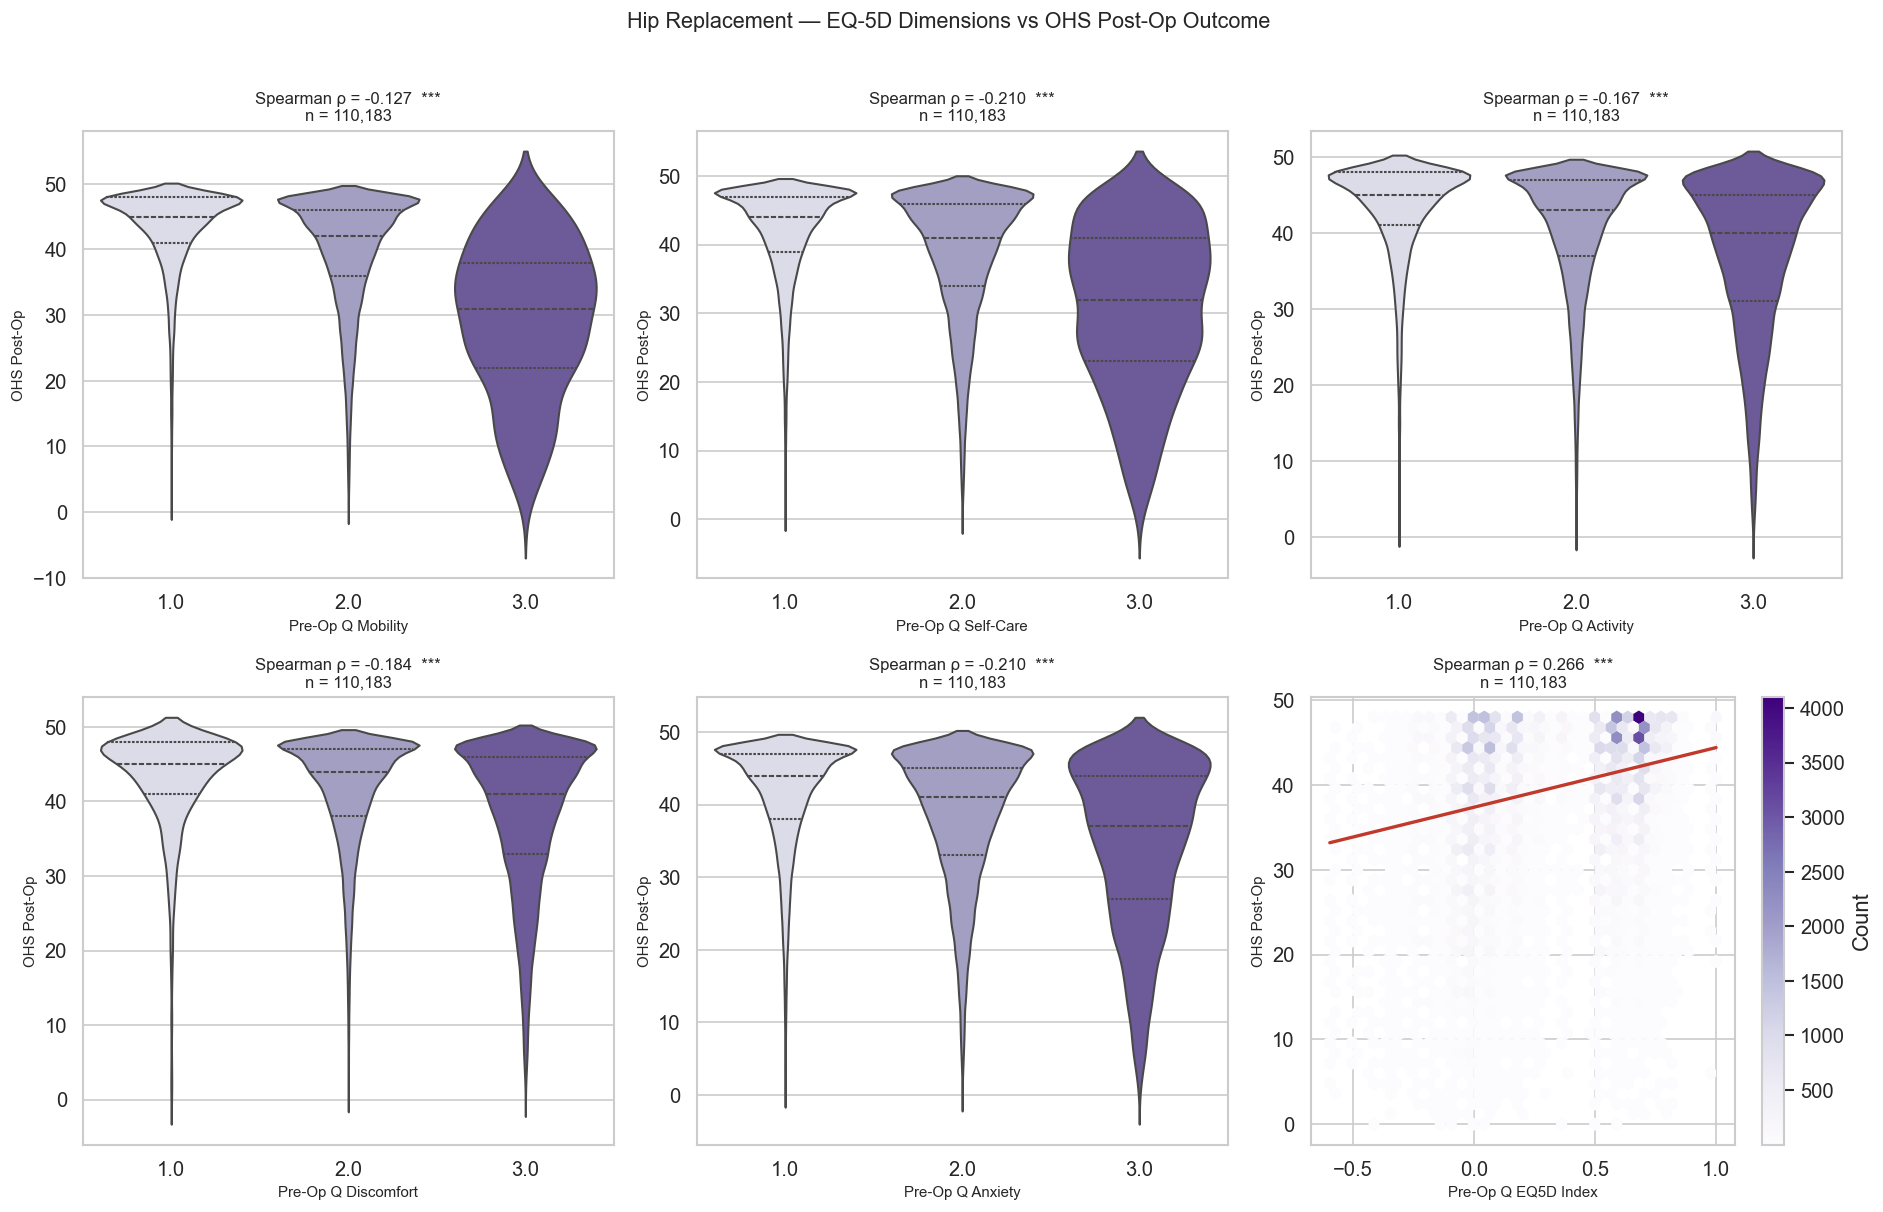

In [12]:
eq5d_dims = [
    'Pre-Op Q Mobility', 'Pre-Op Q Self-Care', 'Pre-Op Q Activity',
    'Pre-Op Q Discomfort', 'Pre-Op Q Anxiety', 'Pre-Op Q EQ5D Index'
]
eq5d_dims = [c for c in eq5d_dims if c in hip.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, dim in enumerate(eq5d_dims):
    ax = axes[i]
    pair = hip[[dim, HIP_OUTCOME]].dropna()
    r, p = stats.spearmanr(pair[dim], pair[HIP_OUTCOME])

    if hip[dim].nunique() <= 5:  # ordinal levels 1-3 → violin
        sns.violinplot(data=pair, x=dim, y=HIP_OUTCOME, palette='Purples', ax=ax, inner='quartile')
    else:                        # continuous (EQ5D Index) → hex-bin
        hb = ax.hexbin(pair[dim], pair[HIP_OUTCOME], gridsize=35, cmap='Purples', mincnt=1, linewidths=0)
        plt.colorbar(hb, ax=ax, label='Count')
        m, b, *_ = stats.linregress(pair[dim], pair[HIP_OUTCOME])
        x_line = np.linspace(pair[dim].min(), pair[dim].max(), 100)
        ax.plot(x_line, m * x_line + b, color=RED, linewidth=2)

    ax.set_xlabel(dim, fontsize=9)
    ax.set_ylabel('OHS Post-Op', fontsize=9)
    ax.set_title(f'Spearman ρ = {r:.3f}  {significance_stars(p)}\nn = {len(pair):,}', fontsize=10)

plt.suptitle('Hip Replacement — EQ-5D Dimensions vs OHS Post-Op Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('hip_eq5d_vs_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## A7 · Comorbidity flags — mean OHS outcome by condition

   Comorbidity  Mean (present)  Mean (absent)  Difference sig  N (present)
   Circulation         33.7511        40.1198     -6.3687 ***         5002
    Depression         35.5236        40.2168     -4.6933 ***         9065
        Stroke         35.9123        39.8825     -3.9702 ***         1436
Nervous System         36.3029        39.8597     -3.5568 ***          898
 Liver Disease         37.1529        39.8473     -2.6944 ***          680
Kidney Disease         37.2803        39.8816     -2.6013 ***         2155
      Diabetes         37.5398        40.0658     -2.5261 ***        10256
  Lung Disease         37.5755        40.0325     -2.4570 ***         9049
 Heart Disease         37.6629        40.0324     -2.3695 ***         9377
     Arthritis         39.4120        40.9176     -1.5056 ***        79542
       High Bp         39.1090        40.2703     -1.1614 ***        41709
        Cancer         39.2423        39.8652     -0.6229 ***         6108


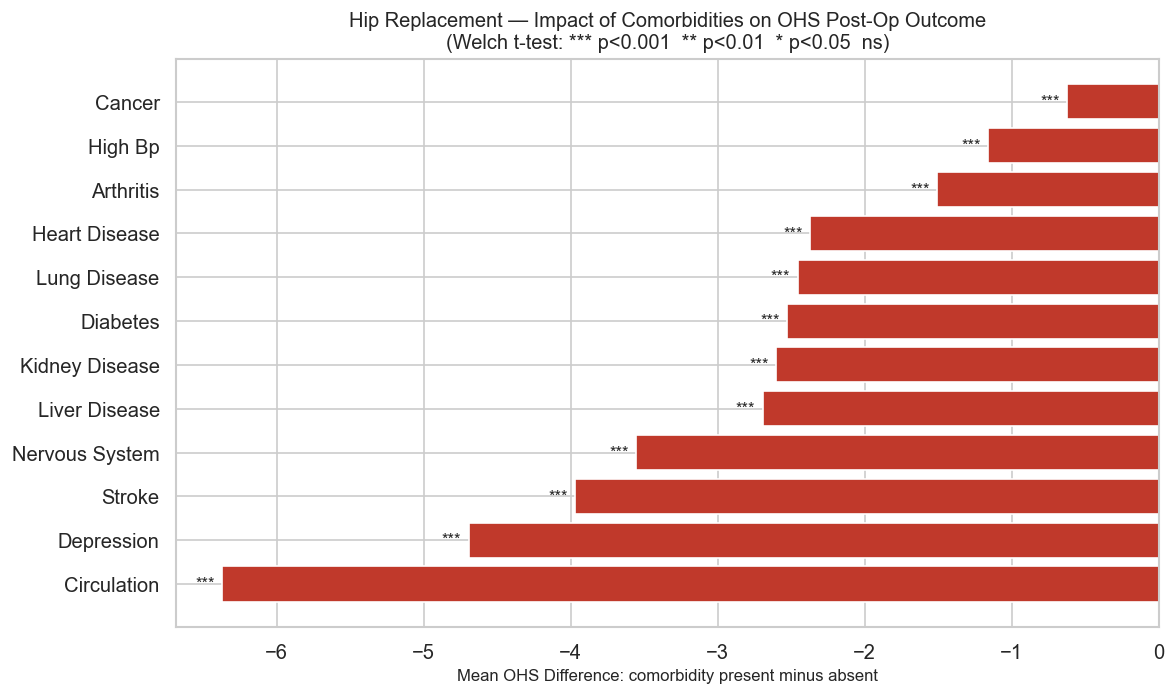

In [13]:
comorbidities = [
    'Arthritis', 'Cancer', 'Circulation', 'Depression', 'Diabetes',
    'Heart Disease', 'High Bp', 'Kidney Disease', 'Liver Disease',
    'Lung Disease', 'Nervous System', 'Stroke'
]
comorbidities = [c for c in comorbidities if c in hip.columns]

# For each comorbidity, compare mean OHS post-op for present (1) vs absent (0)
rows = []
for com in comorbidities:
    present = hip[hip[com] == 1][HIP_OUTCOME].dropna()
    absent  = hip[hip[com] == 0][HIP_OUTCOME].dropna()
    t_stat, p_val = stats.ttest_ind(present, absent, equal_var=False)  # Welch's t-test
    rows.append({
        'Comorbidity': com,
        'Mean (present)': present.mean(),
        'Mean (absent)': absent.mean(),
        'Difference': present.mean() - absent.mean(),
        'p_value': p_val,
        'sig': significance_stars(p_val),
        'N (present)': len(present)
    })
comorbidity_df = pd.DataFrame(rows).sort_values('Difference')
print(comorbidity_df[['Comorbidity','Mean (present)','Mean (absent)','Difference','sig','N (present)']]
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RED if d < 0 else BLUE for d in comorbidity_df['Difference']]
bars = ax.barh(comorbidity_df['Comorbidity'], comorbidity_df['Difference'], color=colors, edgecolor='white')
for bar, (_, row) in zip(bars, comorbidity_df.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height() / 2,
            row['sig'], va='center', ha='left' if x >= 0 else 'right', fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean OHS Difference: comorbidity present minus absent', fontsize=10)
ax.set_title('Hip Replacement — Impact of Comorbidities on OHS Post-Op Outcome\n'
             '(Welch t-test: *** p<0.001  ** p<0.01  * p<0.05  ns)', fontsize=12)
plt.tight_layout()
plt.savefig('hip_comorbidities_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART B — Knee Replacement

## B1 · Full Spearman correlation matrix

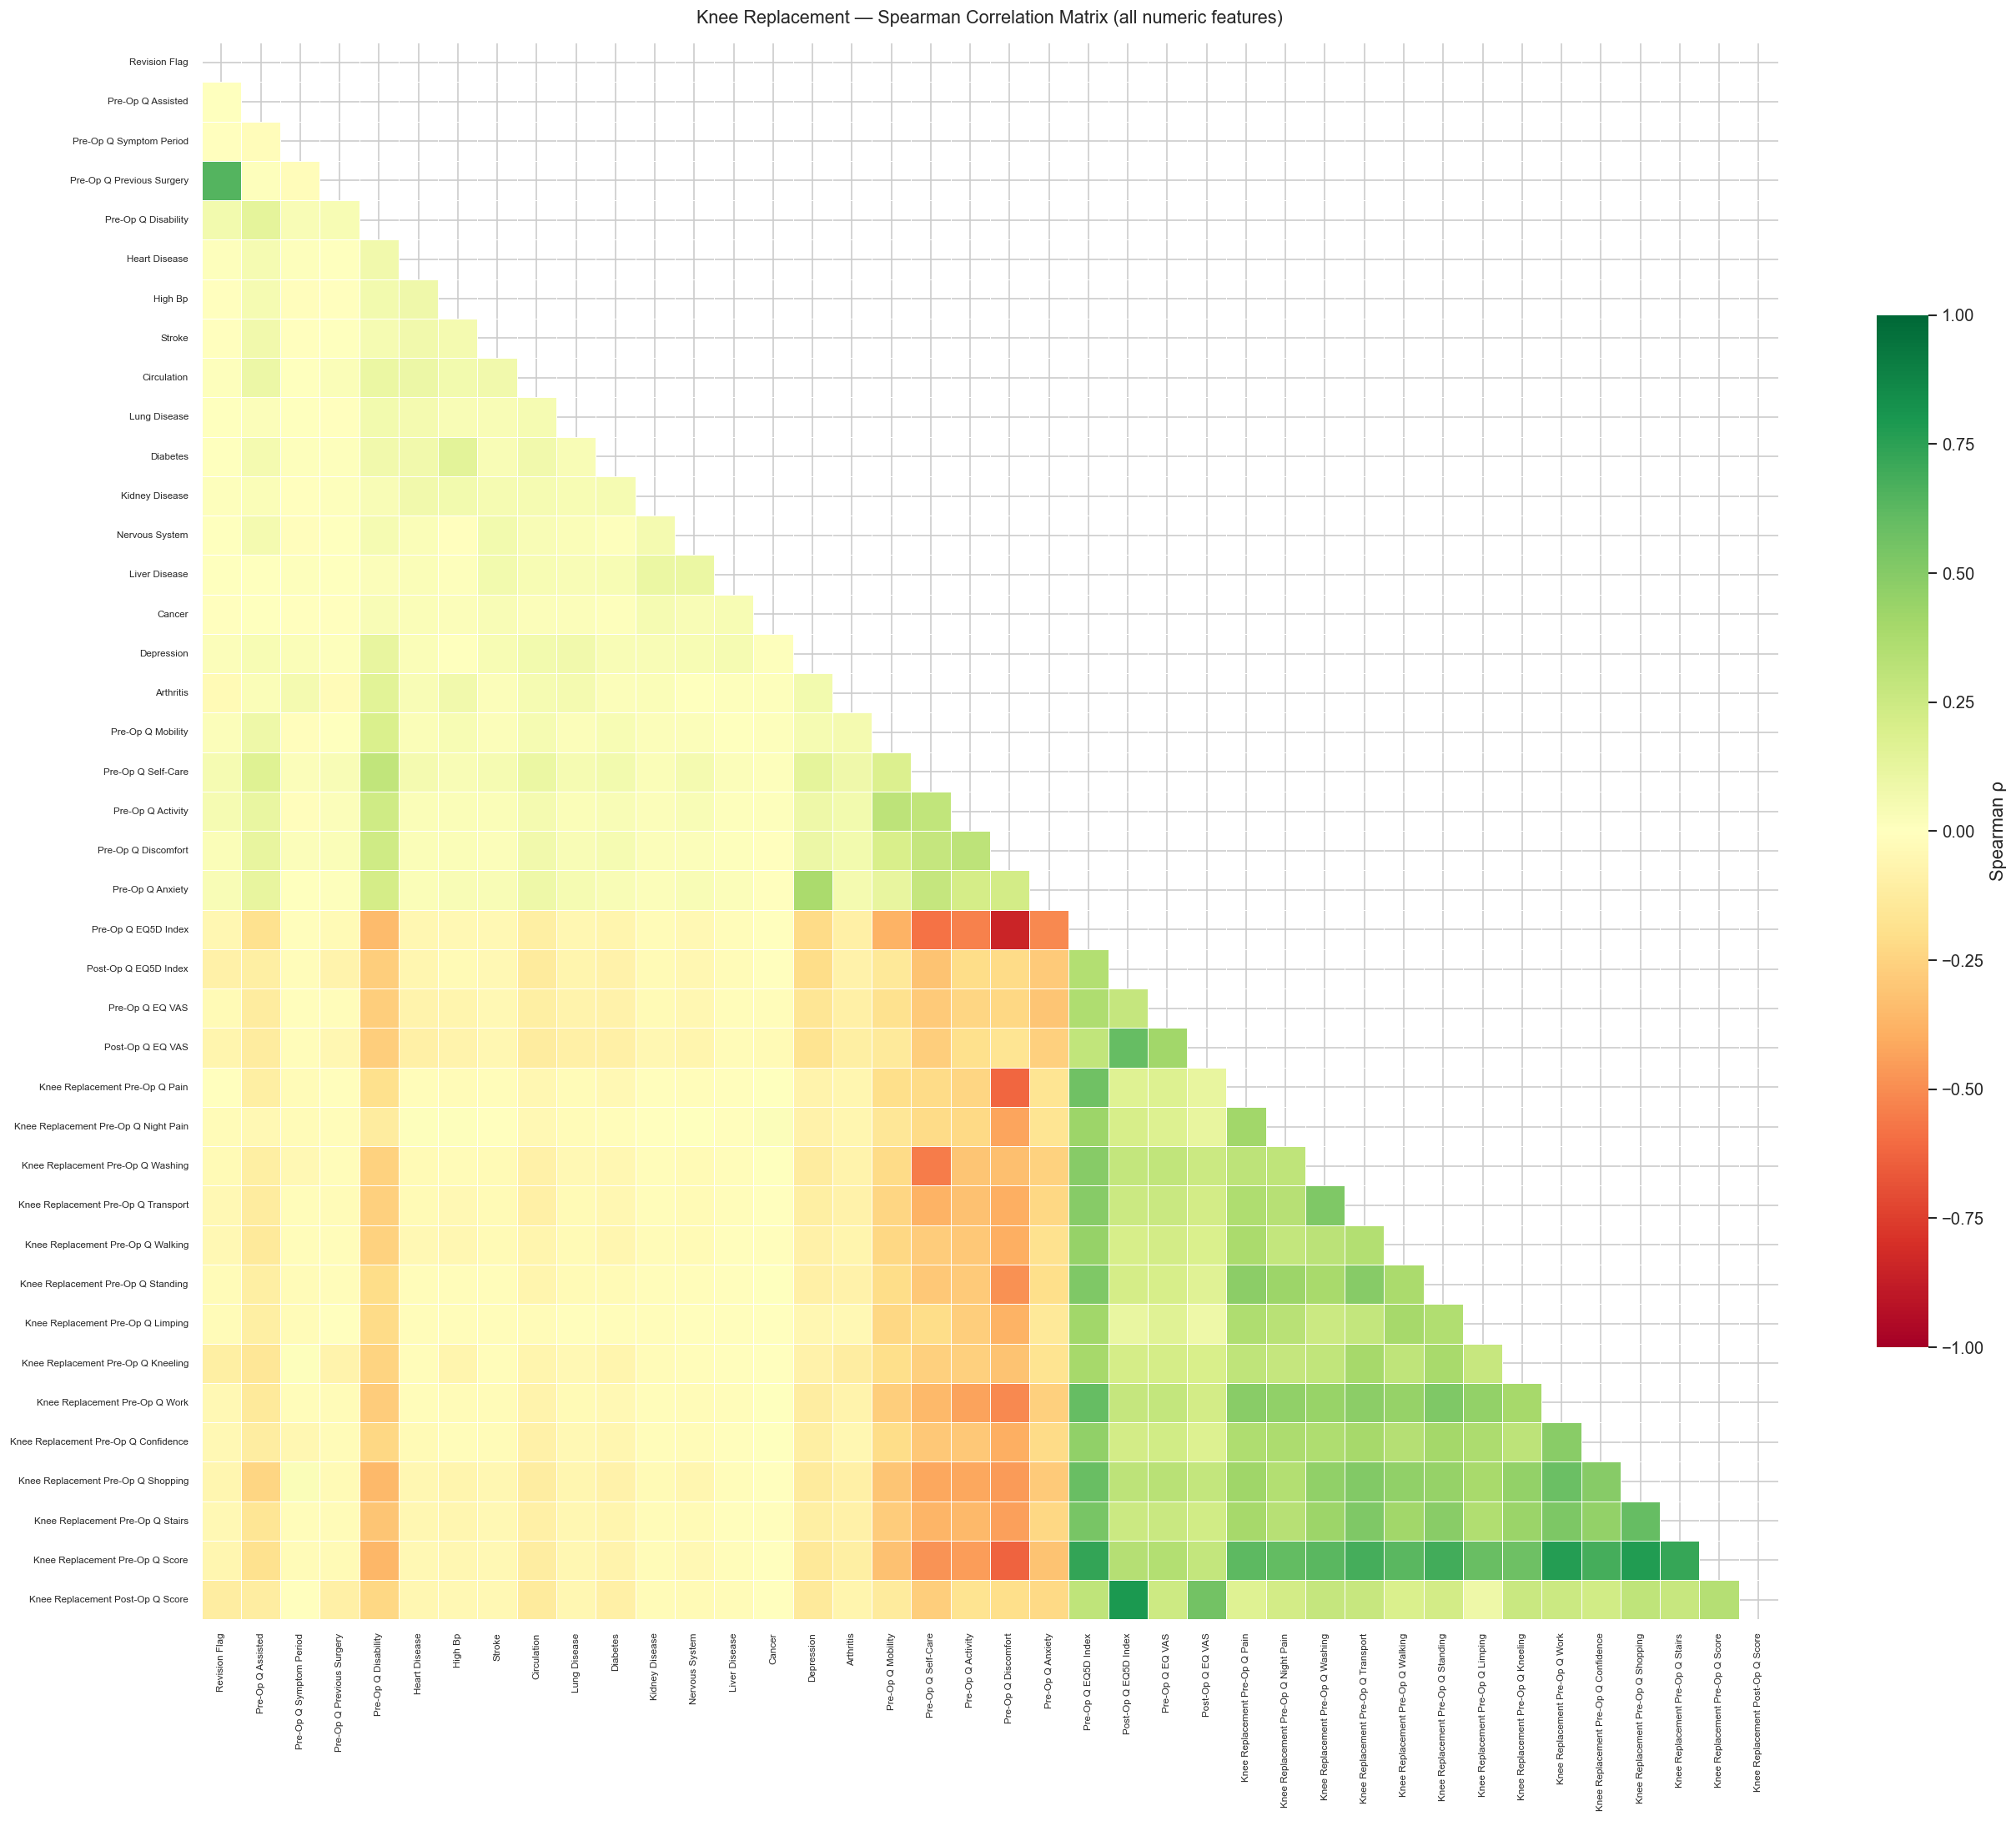

Matrix size: 40 × 40


In [6]:
knee_num_cols = numeric_cols(knee)
knee_corr = knee[knee_num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(22, 19))
mask = np.triu(np.ones_like(knee_corr, dtype=bool))

sns.heatmap(
    knee_corr, mask=mask,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    annot=False, square=True, ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Spearman ρ'}
)
ax.set_title('Knee Replacement — Spearman Correlation Matrix (all numeric features)', pad=14)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig('knee_full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Matrix size: {knee_corr.shape[0]} × {knee_corr.shape[1]}')

## B2 · Ranked correlations — pre-op features vs OKS outcome

In [14]:
knee_preop = preop_cols(knee, KNEE_OUTCOME)
knee_rank  = spearman_with_outcome(knee, knee_preop, KNEE_OUTCOME)

print(f'Pre-op features assessed: {len(knee_rank)}')
print('\nTop 10 positive correlations with OKS post-op:')
print(knee_rank.head(10).to_string(index=False))
print('\nTop 10 negative correlations with OKS post-op:')
print(knee_rank.tail(10).to_string(index=False))

Pre-op features assessed: 37

Top 10 positive correlations with OKS post-op:
                             feature  spearman_r  p_value      n
     Knee Replacement Pre-Op Q Score      0.3398      0.0 127144
  Knee Replacement Pre-Op Q Shopping      0.3013      0.0 127144
                 Pre-Op Q EQ5D Index      0.3006      0.0 127144
   Knee Replacement Pre-Op Q Washing      0.2735      0.0 127144
 Knee Replacement Pre-Op Q Transport      0.2699      0.0 127144
    Knee Replacement Pre-Op Q Stairs      0.2664      0.0 127144
  Knee Replacement Pre-Op Q Kneeling      0.2579      0.0 127144
      Knee Replacement Pre-Op Q Work      0.2545      0.0 127144
                     Pre-Op Q EQ VAS      0.2471      0.0 119155
Knee Replacement Pre-Op Q Confidence      0.2278      0.0 127144

Top 10 negative correlations with OKS post-op:
            feature  spearman_r  p_value      n
  Pre-Op Q Assisted     -0.1113      0.0 127144
      Revision Flag     -0.1133      0.0 127144
  Pre-Op Q Mobil

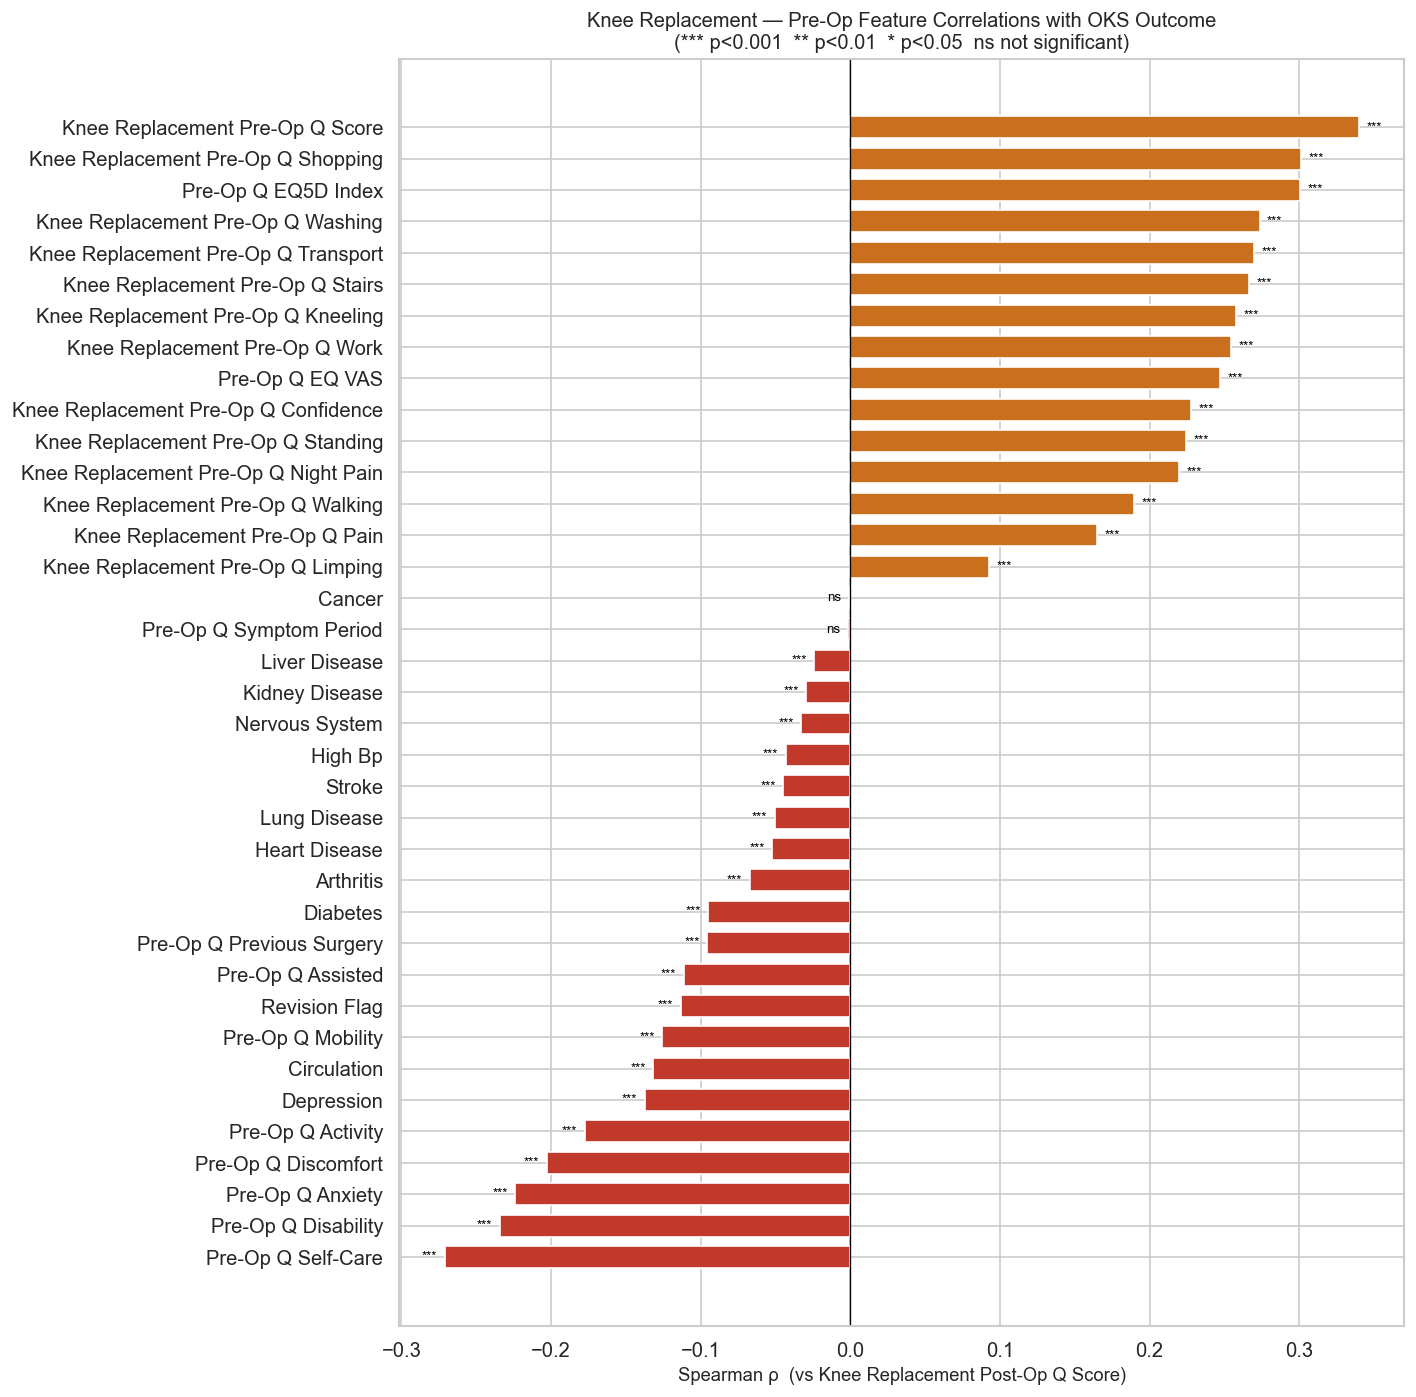

In [15]:
fig, ax = plt.subplots(figsize=(12, max(6, len(knee_rank) * 0.32)))

colors = [ORANGE if r >= 0 else RED for r in knee_rank['spearman_r']]
bars = ax.barh(knee_rank['feature'], knee_rank['spearman_r'], color=colors, edgecolor='white', height=0.7)

for bar, (_, row) in zip(bars, knee_rank.iterrows()):
    stars = significance_stars(row['p_value'])
    x = bar.get_width()
    ax.text(x + (0.005 if x >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            stars, va='center', ha='left' if x >= 0 else 'right', fontsize=8, color='black')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ  (vs Knee Replacement Post-Op Q Score)', fontsize=11)
ax.set_title('Knee Replacement — Pre-Op Feature Correlations with OKS Outcome\n'
             '(*** p<0.001  ** p<0.01  * p<0.05  ns not significant)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('knee_preop_correlations_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

## B3 · Scatter plots — top 6 pre-op predictors vs OKS outcome

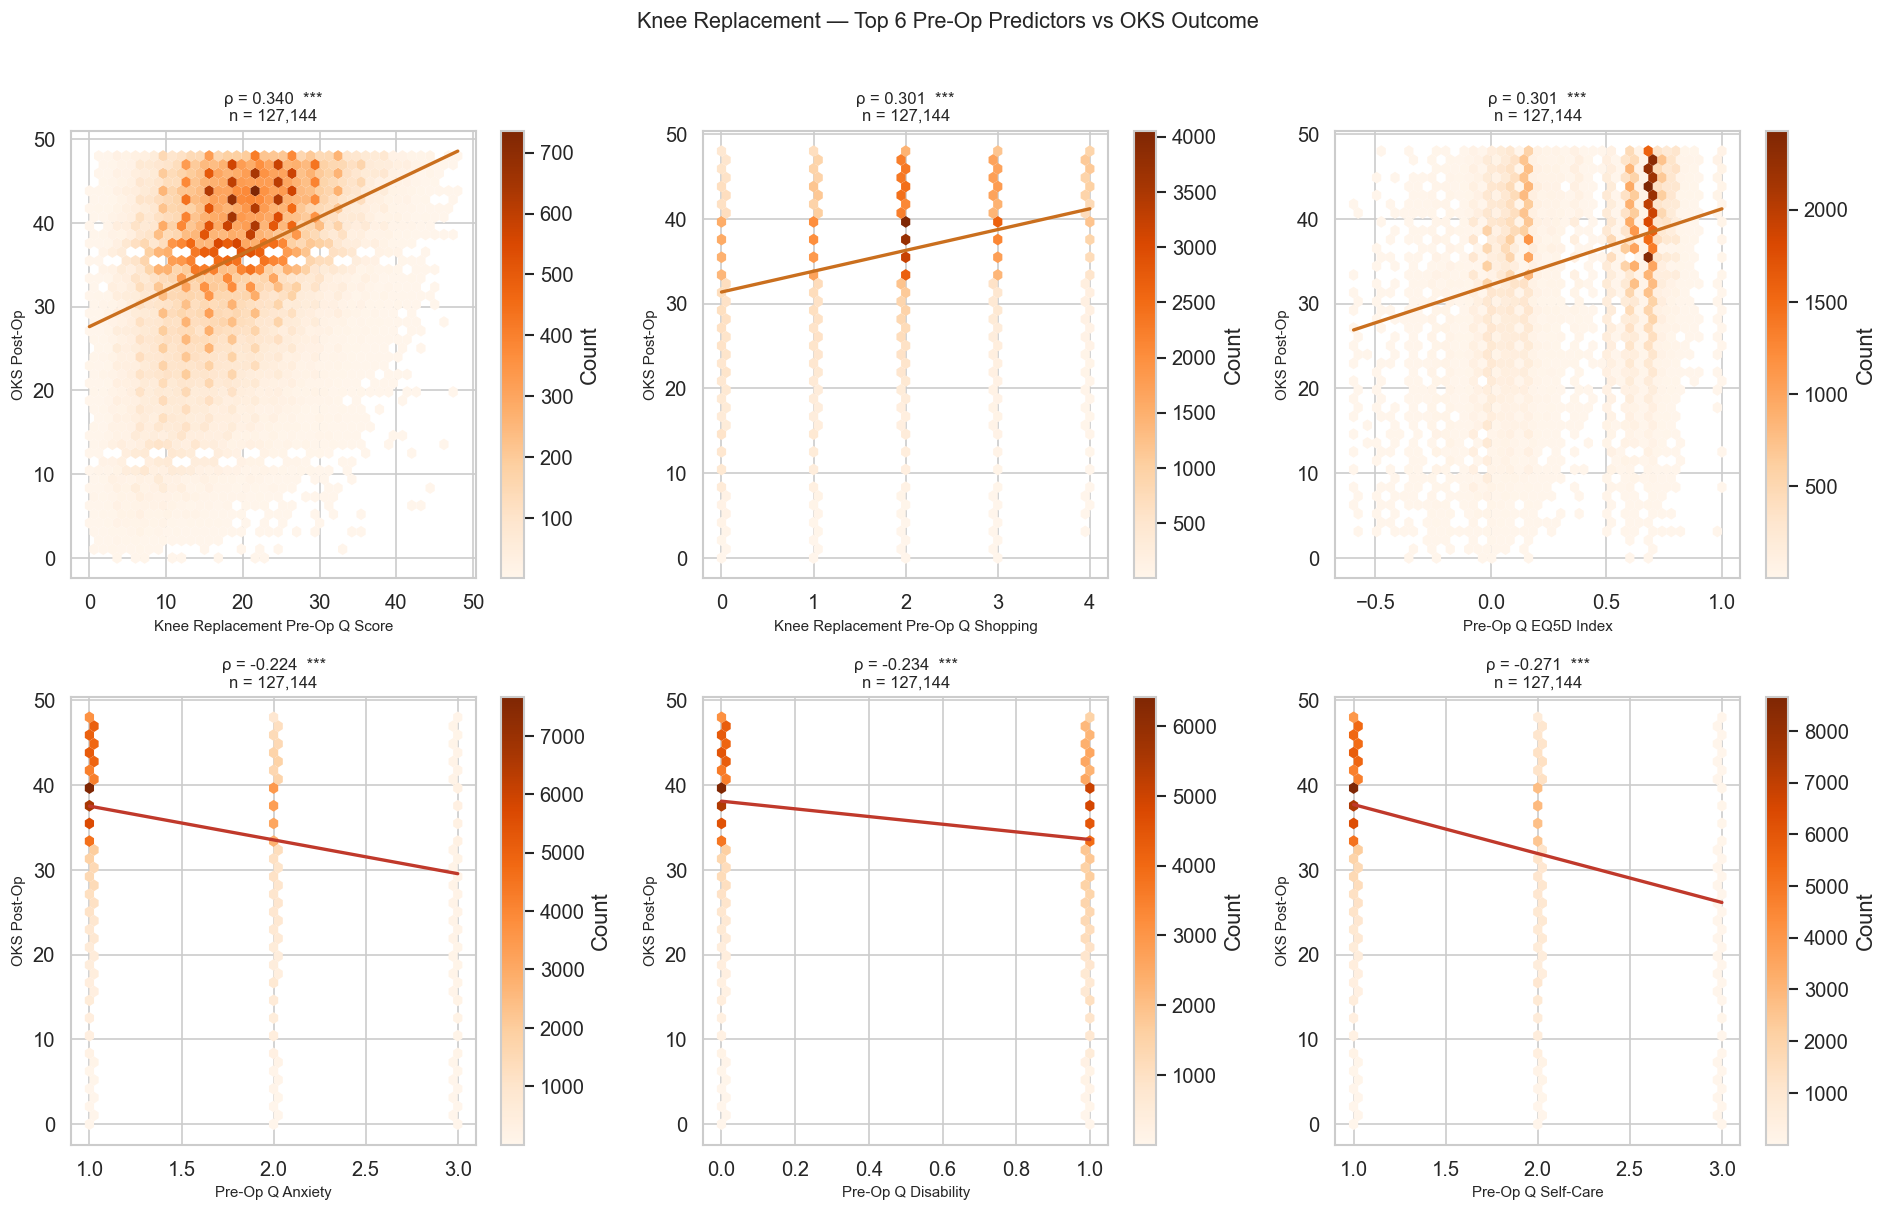

In [16]:
top_pos_k = knee_rank.head(3)['feature'].tolist()
top_neg_k = knee_rank.tail(3)['feature'].tolist()
top6_k    = top_pos_k + top_neg_k

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top6_k):
    ax = axes[i]
    pair = knee[[feat, KNEE_OUTCOME]].dropna()
    r, p = stats.spearmanr(pair[feat], pair[KNEE_OUTCOME])
    color = ORANGE if r >= 0 else RED

    hb = ax.hexbin(pair[feat], pair[KNEE_OUTCOME], gridsize=40, cmap='Oranges', mincnt=1, linewidths=0)
    plt.colorbar(hb, ax=ax, label='Count')

    m, b, *_ = stats.linregress(pair[feat], pair[KNEE_OUTCOME])
    x_line = np.linspace(pair[feat].min(), pair[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color=color, linewidth=2)

    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('OKS Post-Op', fontsize=9)
    ax.set_title(f'ρ = {r:.3f}  {significance_stars(p)}\nn = {len(pair):,}', fontsize=10)

plt.suptitle('Knee Replacement — Top 6 Pre-Op Predictors vs OKS Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('knee_top6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## B4 · Outcome by demographics

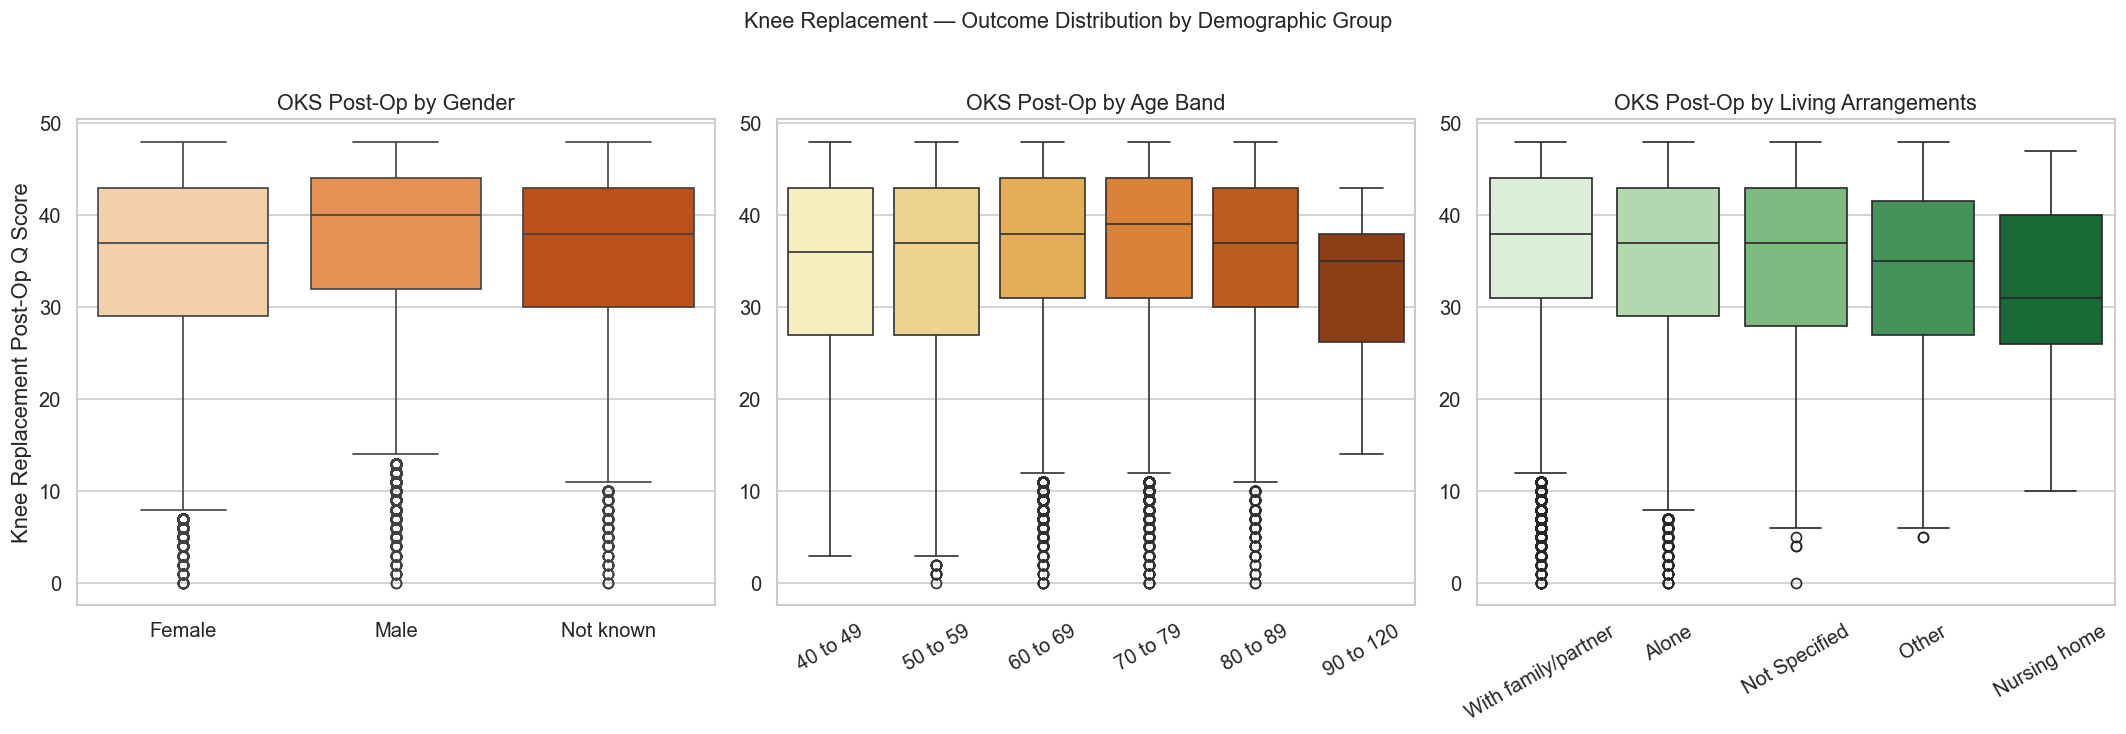

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gender
gender_order_k = knee.dropna(subset=[KNEE_OUTCOME])['Gender'].value_counts().index.tolist()
sns.boxplot(data=knee.dropna(subset=[KNEE_OUTCOME]), x='Gender', y=KNEE_OUTCOME,
            order=gender_order_k, palette='Oranges', ax=axes[0])
axes[0].set_title('OKS Post-Op by Gender')
axes[0].set_xlabel('')
axes[0].set_ylabel('Knee Replacement Post-Op Q Score')

# Age Band
age_order_k = [a for a in ['40 to 49','50 to 59','60 to 69','70 to 79','80 to 89','90 to 120']
               if a in knee['Age Band'].dropna().unique()]
sns.boxplot(data=knee.dropna(subset=[KNEE_OUTCOME]), x='Age Band', y=KNEE_OUTCOME,
            order=age_order_k, palette='YlOrBr', ax=axes[1])
axes[1].set_title('OKS Post-Op by Age Band')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

# Living Arrangements
short_labels_k = {
    'Living with partner/spouse/family/friends': 'With family/partner',
    'Living in a nursing home, hospital or other long-term care home': 'Nursing home',
    'Alone': 'Alone', 'Other': 'Other', 'Not Specified': 'Not Specified'
}
knee_plot = knee.dropna(subset=[KNEE_OUTCOME]).copy()
knee_plot['Living'] = knee_plot['Pre-Op Q Living Arrangements'].map(short_labels_k).fillna(knee_plot['Pre-Op Q Living Arrangements'])
living_order_k = knee_plot.groupby('Living')[KNEE_OUTCOME].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=knee_plot, x='Living', y=KNEE_OUTCOME,
            order=living_order_k, palette='Greens', ax=axes[2])
axes[2].set_title('OKS Post-Op by Living Arrangements')
axes[2].set_xlabel('')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Knee Replacement — Outcome Distribution by Demographic Group', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('knee_demographics_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## B5 · EQ VAS ↔ OKS (extends `correlation-eqvas-ohs.ipynb` for knee)

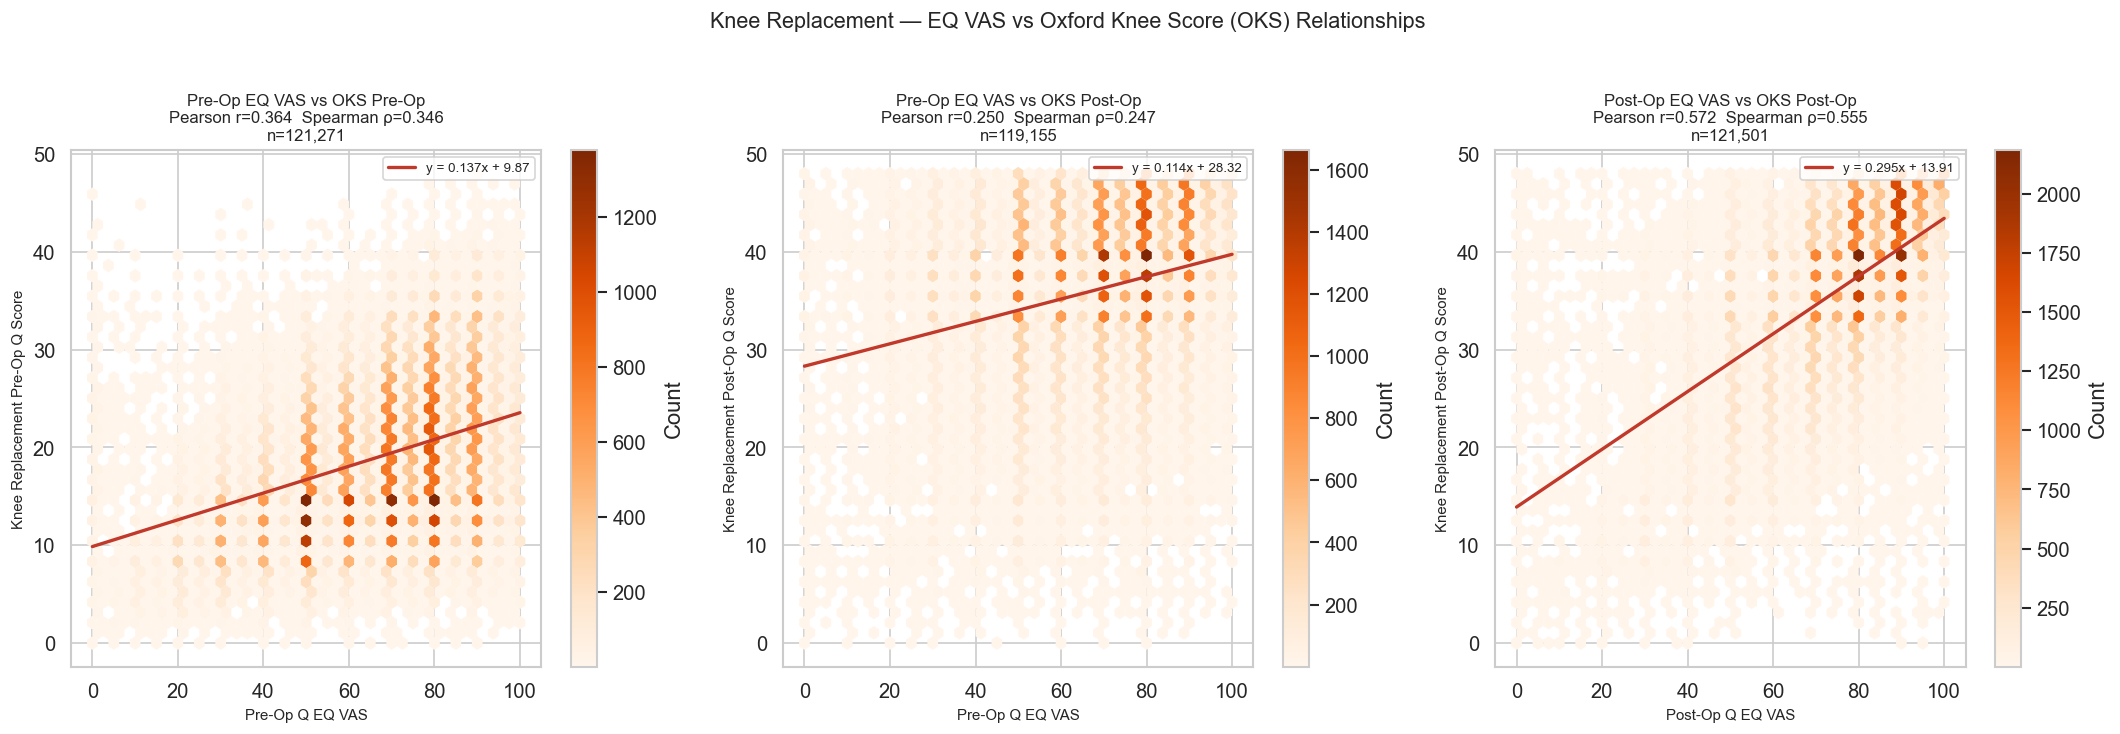

In [18]:
pairs_k = {
    'Pre-Op EQ VAS vs OKS Pre-Op':  ('Pre-Op Q EQ VAS',  'Knee Replacement Pre-Op Q Score'),
    'Pre-Op EQ VAS vs OKS Post-Op': ('Pre-Op Q EQ VAS',  KNEE_OUTCOME),
    'Post-Op EQ VAS vs OKS Post-Op':('Post-Op Q EQ VAS', KNEE_OUTCOME),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, (xcol, ycol)) in zip(axes, pairs_k.items()):
    pair = knee[[xcol, ycol]].dropna()
    pearson_r,  pearson_p  = stats.pearsonr(pair[xcol], pair[ycol])
    spearman_r, spearman_p = stats.spearmanr(pair[xcol], pair[ycol])

    hb = ax.hexbin(pair[xcol], pair[ycol], gridsize=40, cmap='Oranges', mincnt=1, linewidths=0)
    plt.colorbar(hb, ax=ax, label='Count')

    m, b, *_ = stats.linregress(pair[xcol], pair[ycol])
    x_line = np.linspace(pair[xcol].min(), pair[xcol].max(), 100)
    ax.plot(x_line, m * x_line + b, color=RED, linewidth=2,
            label=f'y = {m:.3f}x + {b:.2f}')

    ax.set_xlabel(xcol, fontsize=9)
    ax.set_ylabel(ycol, fontsize=9)
    ax.set_title(f'{title}\nPearson r={pearson_r:.3f}  Spearman ρ={spearman_r:.3f}\nn={len(pair):,}', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Knee Replacement — EQ VAS vs Oxford Knee Score (OKS) Relationships', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('knee_eqvas_oks_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## B6 · Comorbidity flags — mean OKS outcome by condition

   Comorbidity  Mean (present)  Mean (absent)  Difference sig  N (present)
   Circulation         30.4149        36.2493     -5.8344 ***         7011
    Depression         31.4521        36.3899     -4.9378 ***        11905
        Stroke         32.5562        35.9835     -3.4273 ***         2073
Nervous System         32.6921        35.9602     -3.2681 ***         1270
 Liver Disease         32.7386        35.9458     -3.2072 ***          723
      Diabetes         33.5476        36.2647     -2.7171 ***        15776
Kidney Disease         33.9610        35.9681     -2.0071 ***         2567
  Lung Disease         34.3492        36.0857     -1.7365 ***        11578
 Heart Disease         34.3764        36.0873     -1.7109 ***        11872
     Arthritis         35.6228        36.9740     -1.3513 ***        98463
       High Bp         35.5491        36.2294     -0.6802 ***        56409
        Cancer         35.9528        35.9261      0.0266  ns         6882


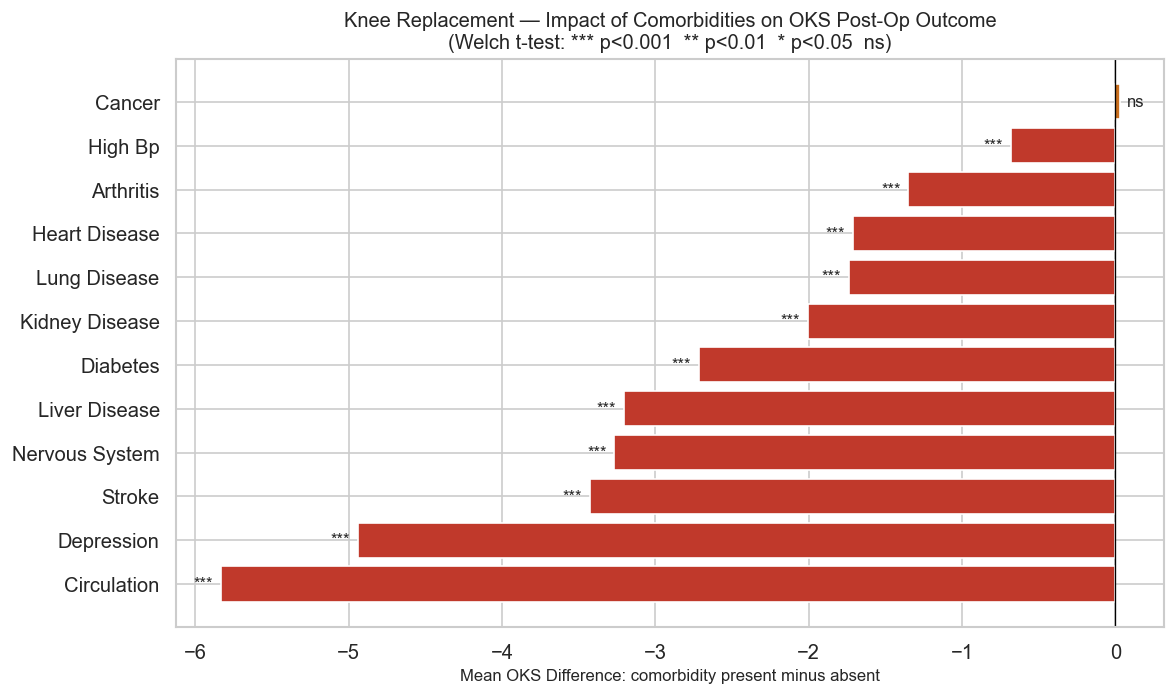

In [19]:
rows_k = []
for com in comorbidities:
    if com not in knee.columns:
        continue
    present = knee[knee[com] == 1][KNEE_OUTCOME].dropna()
    absent  = knee[knee[com] == 0][KNEE_OUTCOME].dropna()
    t_stat, p_val = stats.ttest_ind(present, absent, equal_var=False)
    rows_k.append({
        'Comorbidity': com,
        'Mean (present)': present.mean(),
        'Mean (absent)': absent.mean(),
        'Difference': present.mean() - absent.mean(),
        'p_value': p_val,
        'sig': significance_stars(p_val),
        'N (present)': len(present)
    })
comorbidity_df_k = pd.DataFrame(rows_k).sort_values('Difference')
print(comorbidity_df_k[['Comorbidity','Mean (present)','Mean (absent)','Difference','sig','N (present)']]
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RED if d < 0 else ORANGE for d in comorbidity_df_k['Difference']]
bars = ax.barh(comorbidity_df_k['Comorbidity'], comorbidity_df_k['Difference'], color=colors, edgecolor='white')
for bar, (_, row) in zip(bars, comorbidity_df_k.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.05 if x >= 0 else -0.05), bar.get_y() + bar.get_height() / 2,
            row['sig'], va='center', ha='left' if x >= 0 else 'right', fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean OKS Difference: comorbidity present minus absent', fontsize=10)
ax.set_title('Knee Replacement — Impact of Comorbidities on OKS Post-Op Outcome\n'
             '(Welch t-test: *** p<0.001  ** p<0.01  * p<0.05  ns)', fontsize=12)
plt.tight_layout()
plt.savefig('knee_comorbidities_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART C — Cross-dataset comparison (Hip vs Knee)

## C1 · Shared feature correlation comparison

Features present in **both** datasets are compared side-by-side to show whether the same
predictors are equally important for hip and knee outcomes.

In [20]:
# Build comparable feature sets using only shared column names
shared_features = sorted(
    set(hip_rank['feature']) & set(knee_rank['feature'])
)

hip_shared  = hip_rank[hip_rank['feature'].isin(shared_features)].set_index('feature')['spearman_r']
knee_shared = knee_rank[knee_rank['feature'].isin(shared_features)].set_index('feature')['spearman_r']

compare_df = pd.DataFrame({'Hip (OHS)': hip_shared, 'Knee (OKS)': knee_shared}).dropna()
compare_df = compare_df.reindex(compare_df['Hip (OHS)'].sort_values(ascending=False).index)

print(f'Shared features compared: {len(compare_df)}')
print(compare_df.round(3).to_string())

Shared features compared: 24
                           Hip (OHS)  Knee (OKS)
feature                                         
Pre-Op Q EQ5D Index            0.266       0.301
Pre-Op Q EQ VAS                0.209       0.247
Cancer                        -0.021      -0.001
Liver Disease                 -0.022      -0.024
Nervous System                -0.037      -0.033
Kidney Disease                -0.039      -0.030
Stroke                        -0.050      -0.045
Pre-Op Q Symptom Period       -0.057      -0.002
Lung Disease                  -0.074      -0.050
High Bp                       -0.080      -0.043
Heart Disease                 -0.082      -0.052
Diabetes                      -0.086      -0.095
Arthritis                     -0.089      -0.067
Pre-Op Q Previous Surgery     -0.104      -0.095
Revision Flag                 -0.124      -0.113
Pre-Op Q Mobility             -0.127      -0.126
Depression                    -0.128      -0.137
Circulation                   -0.142    

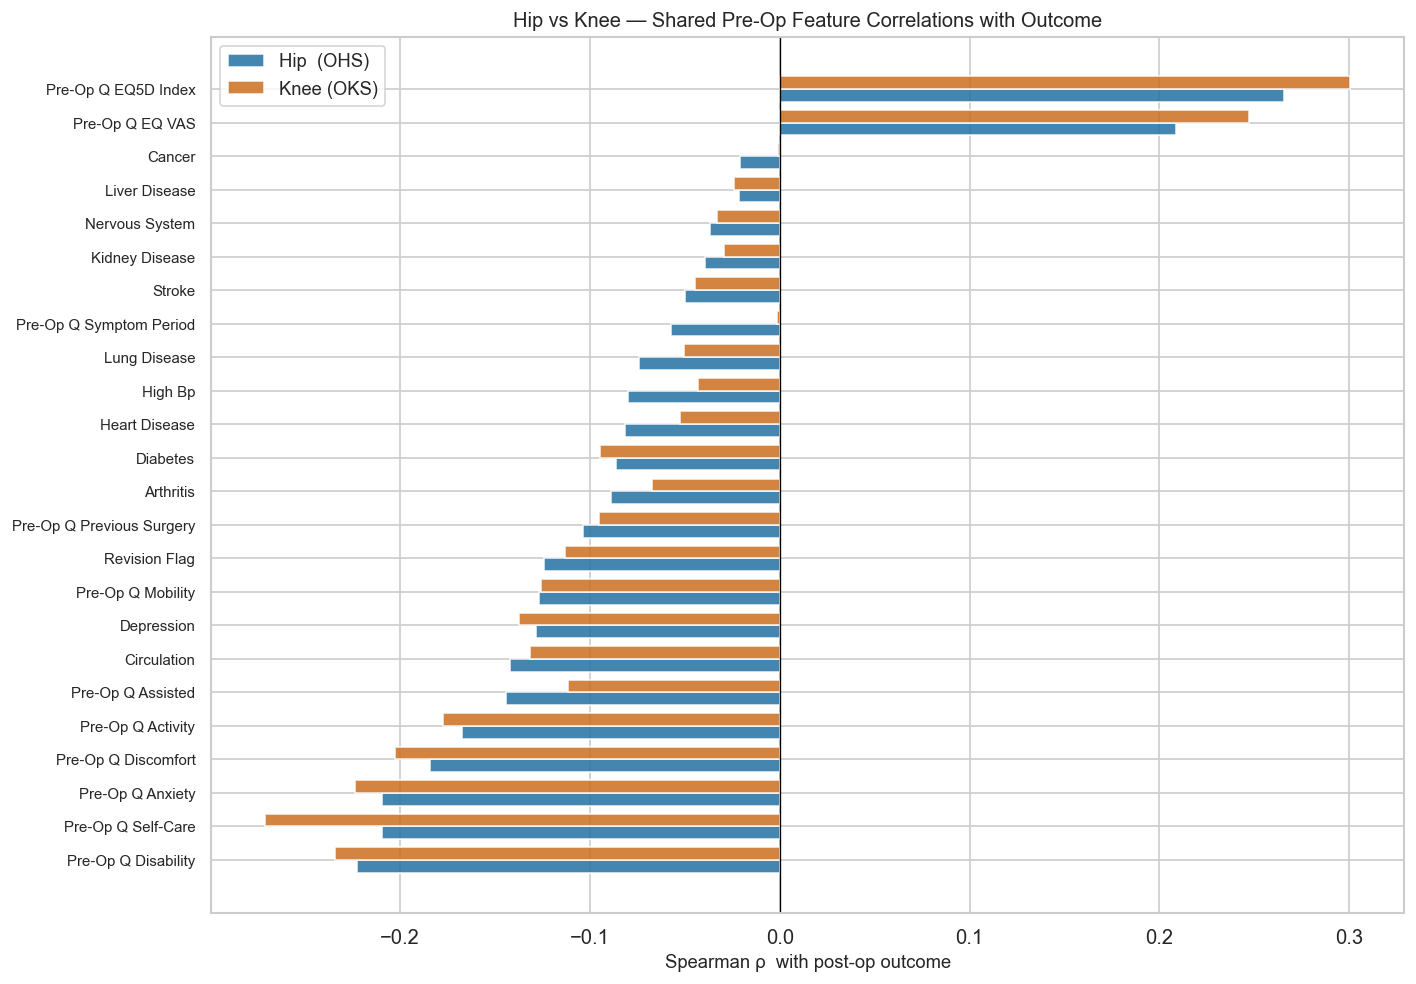

In [21]:
fig, ax = plt.subplots(figsize=(12, max(6, len(compare_df) * 0.35)))

x = np.arange(len(compare_df))
width = 0.38
ax.barh(x + width/2, compare_df['Hip (OHS)'],  width, label='Hip  (OHS)',  color=BLUE,   edgecolor='white', alpha=0.85)
ax.barh(x - width/2, compare_df['Knee (OKS)'], width, label='Knee (OKS)', color=ORANGE, edgecolor='white', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(compare_df.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman ρ  with post-op outcome', fontsize=11)
ax.set_title('Hip vs Knee — Shared Pre-Op Feature Correlations with Outcome', fontsize=12)
ax.legend(fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('hip_vs_knee_shared_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## C2 · Scatter of Hip correlation vs Knee correlation (shared features)

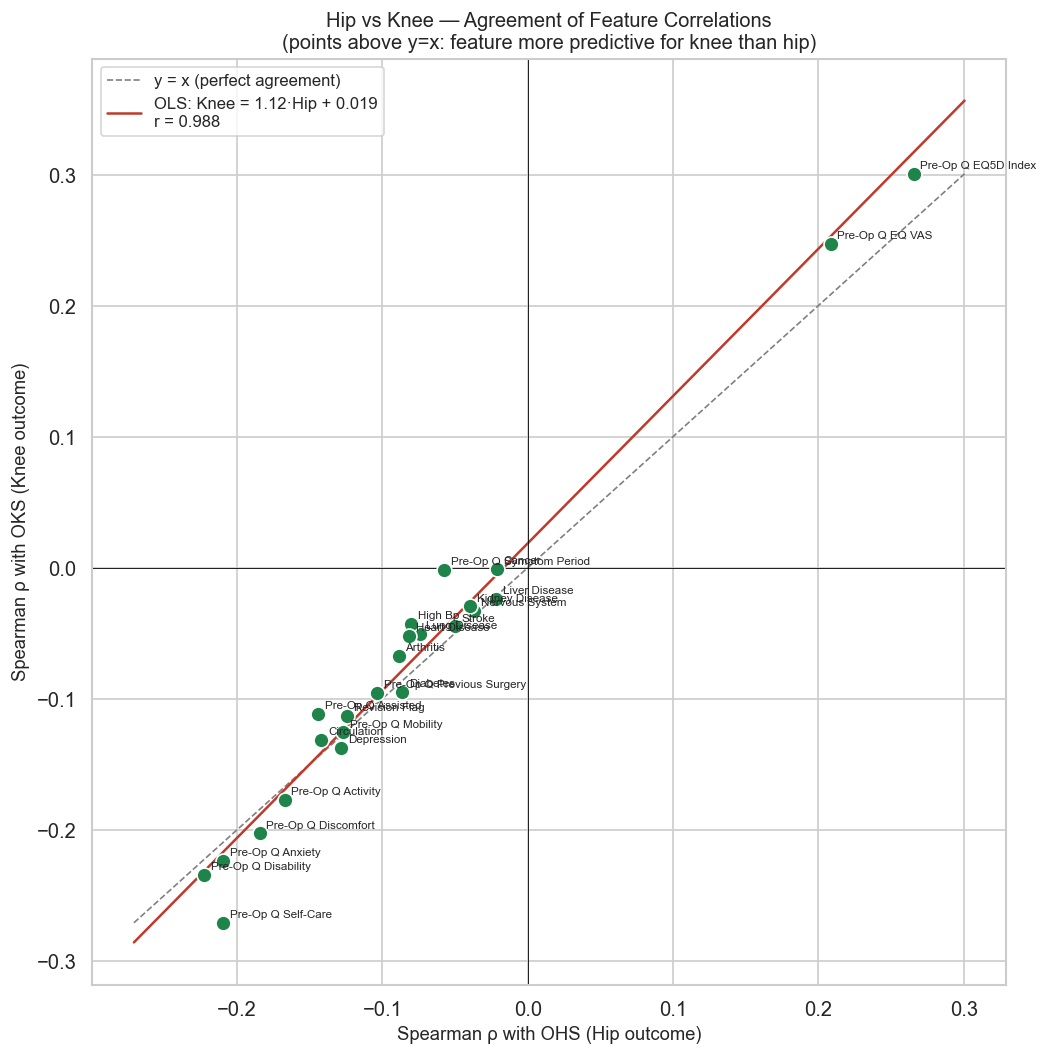


Pearson r between hip and knee correlations: 0.988  (p = 2.25e-19)
A high r indicates that the same features tend to be predictive in both procedures.


In [22]:
fig, ax = plt.subplots(figsize=(9, 9))

ax.scatter(compare_df['Hip (OHS)'], compare_df['Knee (OKS)'],
           color=GREEN, edgecolors='white', s=80, zorder=3)

# Annotate each point
for feat, row in compare_df.iterrows():
    ax.annotate(feat, (row['Hip (OHS)'], row['Knee (OKS)']),
                fontsize=7, ha='left', va='bottom',
                xytext=(4, 2), textcoords='offset points')

# Diagonal line y=x (perfect agreement between datasets)
lims = [min(compare_df.min()), max(compare_df.max())]
ax.plot(lims, lims, '--', color='grey', linewidth=1, label='y = x (perfect agreement)')

# OLS fit
m, b, r, p, _ = stats.linregress(compare_df['Hip (OHS)'], compare_df['Knee (OKS)'])
x_fit = np.linspace(*lims, 100)
ax.plot(x_fit, m * x_fit + b, color=RED, linewidth=1.5,
        label=f'OLS: Knee = {m:.2f}·Hip + {b:.3f}\nr = {r:.3f}')

ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Spearman ρ with OHS (Hip outcome)', fontsize=11)
ax.set_ylabel('Spearman ρ with OKS (Knee outcome)', fontsize=11)
ax.set_title('Hip vs Knee — Agreement of Feature Correlations\n'
             '(points above y=x: feature more predictive for knee than hip)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('hip_vs_knee_correlation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPearson r between hip and knee correlations: {r:.3f}  (p = {p:.2e})')
print('A high r indicates that the same features tend to be predictive in both procedures.')

## C3 · Summary table — top 15 predictors for each dataset

In [23]:
top15_hip  = hip_rank.head(15)[['feature', 'spearman_r', 'p_value']].rename(
    columns={'feature': 'Feature (Hip)', 'spearman_r': 'ρ (Hip)', 'p_value': 'p (Hip)'})
top15_knee = knee_rank.head(15)[['feature', 'spearman_r', 'p_value']].rename(
    columns={'feature': 'Feature (Knee)', 'spearman_r': 'ρ (Knee)', 'p_value': 'p (Knee)'})

top15_hip  = top15_hip.reset_index(drop=True)
top15_knee = top15_knee.reset_index(drop=True)

top15_hip['sig (Hip)']  = top15_hip['p (Hip)'].apply(significance_stars)
top15_knee['sig (Knee)']= top15_knee['p (Knee)'].apply(significance_stars)

summary = pd.concat([
    top15_hip[['Feature (Hip)', 'ρ (Hip)', 'sig (Hip)']],
    top15_knee[['Feature (Knee)', 'ρ (Knee)', 'sig (Knee)']]
], axis=1)

summary.index = range(1, 16)
summary['ρ (Hip)']  = summary['ρ (Hip)'].round(4)
summary['ρ (Knee)'] = summary['ρ (Knee)'].round(4)

print('=== Top 15 pre-op predictors by Spearman ρ ===')
print(summary.to_string())

=== Top 15 pre-op predictors by Spearman ρ ===
                           Feature (Hip)  ρ (Hip) sig (Hip)                        Feature (Knee)  ρ (Knee) sig (Knee)
1      Hip Replacement Pre-Op Q Shopping   0.2901       ***       Knee Replacement Pre-Op Q Score    0.3398        ***
2        Hip Replacement Pre-Op Q Stairs   0.2808       ***    Knee Replacement Pre-Op Q Shopping    0.3013        ***
3         Hip Replacement Pre-Op Q Score   0.2723       ***                   Pre-Op Q EQ5D Index    0.3006        ***
4                    Pre-Op Q EQ5D Index   0.2657       ***     Knee Replacement Pre-Op Q Washing    0.2735        ***
5     Hip Replacement Pre-Op Q Transport   0.2238       ***   Knee Replacement Pre-Op Q Transport    0.2699        ***
6          Hip Replacement Pre-Op Q Work   0.2143       ***      Knee Replacement Pre-Op Q Stairs    0.2664        ***
7       Hip Replacement Pre-Op Q Walking   0.2091       ***    Knee Replacement Pre-Op Q Kneeling    0.2579        ***
8